In [13]:
# -*- coding: utf-8 -*-
"""
Notebook con el fin de procesar tanto los resultados de las pruebas de clasificacion y segmentacion, como la base de datos de embarcaciones
y generar estadisticas y graficas de los resultados obtenidos.
Actualizado: 13 de octubre de 2025
"""
# ---------------- Librerias -------------------------------------------------------------------------------
# Librerias matematicas
import numpy as np
import math
import statistics as stats

# Librerias graficas
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Librerias de manejo de datos
import csv
import os
from datetime import datetime
import re
import pandas as pd

# Librerias de manejo de datos geoespaciales
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from pyproj import Transformer

# ---------------- Funciones -------------------------------------------------------------------------------
def xywh_to_xyxy(box: list) -> list:
    """
    Convierte el formato de yolo (x_center, y_center, width, height) a (x_min, y_min, x_max, y_max).

    Args:
        box (list): Lista que contiene las coordenadas de la caja en formato (x_center, y_center, width, height).

    Returns:
        list: Retorna una lista con las coordenadas en el formato (x_min, y_min, x_max, y_max).
    """
    x, y, w, h = box    # Desempaquetar las coordenadas
    x_min = x - w / 2   # Calcular las coordenadas minimas y maximas
    y_min = y - h / 2
    x_max = x + w / 2
    y_max = y + h / 2

    return [x_min, y_min, x_max, y_max] # Retornar las coordenadas en el nuevo formato

def IoU(boxA: list, boxB: list) -> float:
    """
    Calcula el Intersection over Union (IoU) entre dos cajas.

    Args:
        boxA (list): Lista que contiene las coordenadas de la caja A en formato (x_center, y_center, width, height).
        boxB (list): Lista que contiene las coordenadas de la caja B en formato (x_center, y_center, width, height).

    Returns:
        float: Retorna el valor del IoU entre las dos cajas.
    """

    boxA = xywh_to_xyxy(boxA)   # Convertir las cajas al formato (x_min, y_min, x_max, y_max)
    boxB = xywh_to_xyxy(boxB)
   
    xA = max(boxA[0], boxB[0])  # Calcular las coordenadas del area de interseccion
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)                   # Calcular el area de interseccion
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])            # Calcular el area de ambas cajas
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])            
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-9) # Calcular el IoU
    
    return iou

def extract_number(value: str) -> float:
    """
    Extrae un número de un string.

    Args:
        value (str): El string del cual se extraerá el número.

    Returns:
        float: El número extraído o None si no se encontró un número.
    """
    match = re.search(r"[-+]?\d*\.?\d+", value)     # Buscar un patrón numérico en el string
    return float(match.group()) if match else None  # Retornar el número como float o None si no se encontró

def modelo_sort_key(modelo: str, type_order: list, size_order: list) -> tuple:
    """
    Genera una clave de ordenamiento para un modelo basado en su tipo y tamaño.
    
    Args:
        modelo      (str): El nombre del modelo en el formato "Modelo_size_type".
        type_order (list): Lista que define el orden de los tipos.
        size_order (list): Lista que define el orden de los tamaños.
    
    Returns:
        tuple: Una tupla que contiene los índices del tipo y tamaño en sus respectivas listas de orden.
    """
    _, size, tipo = modelo.split("_")                               # Dividir el nombre del modelo para obtener tamaño y tipo   
    return (type_order.index(tipo), size_order.index(int(size)))    # Retornar una tupla con los índices del tipo y tamaño

def Clasification_Results(Ruta_Archivo: str) -> dict:
    """
    Genera un diccionario con los resultados de clasificación a partir de un archivo CSV.

    Args:
        Ruta_Archivo (str): La ruta del archivo CSV de entrada.
    
    Returns:
        dict: Un diccionario con los resultados de clasificación.
    """

    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]       # Extraer el nombre del dispositivo del nombre del archivo
    Model={Nombre_Dispositivo: {}}                                              # Inicializar el diccionario de resultados                              

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:  # Abrir el archivo CSV
        reader = csv.DictReader(infile)                                         # Leer el archivo CSV como un diccionario
        header = reader.fieldnames                                              # Obtener los nombres de las columnas

        # ---------------- Inicializacion de los diccionarios de resultado para cada modelo ----------------

        for header_index in range(len(header)):                                 # Iterar sobre los nombres de las columnas
            model_name = header[header_index].split(' - ')[0]                   # Extraer el nombre del modelo
            Data_type = header[header_index].split(' - ')[-1]                   # Extraer el tipo de dato
            
            if(Data_type == 'prediction'):                                      # Si el tipo de dato es 'prediction', inicializar las métricas
                Model[Nombre_Dispositivo][model_name] = {  
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[]
                    }
        # ---------------- Llenado de la base de datos para cada modelo ------------------------------------
                   
        for row in reader:                                                      # Iterar sobre cada fila del archivo CSV
            for field, column in row.items():                                   # Iterar sobre cada columna de la fila
                model_name = field.split(' - ')[0]                              # Extraer el nombre del modelo
                Data_type = field.split(' - ')[-1]                              # Extraer el tipo de dato
                
                if(Data_type == 'prediction'):                                          # Si el tipo de dato es 'prediction', actualizar las métricas
                    if(row['Main_Label']==column):                                      # Si la predicción entre la base de datos y los resultados coinciden
                        if(column=='1'):                                                # Si la predicción es positiva, incrementar el contador de verdaderos positivos
                            Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1     
                        else:                                                           # Si la predicción es negativa, incrementar el contador de verdaderos negativos
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                    else:       
                        if(column=='1'):                                                # Si la predicción es positiva, pero la base de datos es negativa, incrementar el contador de falsos positivos
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:                                                           # Si la predicción es negativa, pero la base de datos es positiva, incrementar el contador de falsos negativos
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1
                
                elif(Data_type == 'conf'):                                              # Si el tipo de dato es 'conf', agregar la probabilidad a la lista
                    Model[Nombre_Dispositivo][model_name]['Probs'].append(float(column))

                elif(Data_type == 'time [ms]'):                                         # Si el tipo de dato es 'time [ms]', agregar el tiempo a la lista
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model

def Segmentation_Results(Ruta_Archivo: str) -> dict:
    """
    Genera un diccionario con los resultados de clasificación a partir de un archivo CSV.

    Args:
        Ruta_Archivo (str): La ruta del archivo CSV de entrada.
    
    Returns:
        dict: Un diccionario con los resultados de segmentacion.
    """

    Nombre_Dispositivo = Ruta_Archivo.split("Results_")[-1].split("_")[0]           # Extraer el nombre del dispositivo del nombre del archivo
    Model={Nombre_Dispositivo: {}}                                                  # Inicializar el diccionario de resultados 

    with open(Ruta_Archivo, mode="r", newline='', encoding='utf-8') as infile:      # Abrir el archivo CSV
        reader = csv.DictReader(infile)                                             # Leer el archivo CSV como un diccionario
        header = reader.fieldnames                                                  # Obtener los nombres de las columnas

        # ---------------- Inicializacion de los diccionarios de resultado para cada modelo ----------------

        for header_index in range(len(header)):                                     # Iterar sobre los nombres de las columnas
            model_name = header[header_index].split(' - ')[0]                       # Extraer el nombre del modelo
            Data_type = header[header_index].split(' - ')[-1]                       # Extraer el tipo de dato
            
            if(Data_type == 'prediction'):                                          # Si el tipo de dato es 'prediction', inicializar las métricas
                Model[Nombre_Dispositivo][model_name] = { 
                    'Embarcacion': 0,
                    'Falso_Negativo':0,
                    'Falso_Positivo':0,
                    'No_Embarcacion':0,
                    'Probs':[],
                    'Speed':[],
                    'IoU':[]
                    }
        
        # ---------------- Llenado de la base de datos para cada modelo ------------------------------------

        for  row in reader:                                                         # Iterar sobre cada fila del archivo CSV
            for field, column in row.items():                                       # Iterar sobre cada columna de la fila
                model_name = field.split(' - ')[0]                                  # Extraer el nombre del modelo
                Data_type = field.split(' - ')[-1]                                  # Extraer el tipo de dato
                
                if(Data_type == 'prediction'):                                          # Si el tipo de dato es 'prediction', actualizar las métricas
                    if(row['Main_Label']==column):                                      # Si la predicción entre la base de datos y los resultados coinciden
                        if(column=='0'):                                                # Si la predicción es negativa, incrementar el contador de verdaderos negativos
                            Model[Nombre_Dispositivo][model_name]['No_Embarcacion']+=1
                        else:                                                           # Si la predicción es positiva, procesar las segmentaciones
                            # Procesar las segmentaciones de la base de datos
                            DB_Segments = row['Segments']
                            DB_Segments = DB_Segments.strip("[]").split(",")
                            DB_Segments = [item.strip().strip("'").strip('"').strip().split() for item in DB_Segments]   
                            DB_Segments =  [list(map(float,item[1:])) for item in DB_Segments]        
                            
                            # Procesar las segmentaciones de los resultados del modelo
                            YOLO_Segments = row[f"{model_name} - segment"]
                            YOLO_Segments = YOLO_Segments.strip("[]").split(",")
                            YOLO_Segments = [item.strip().strip("'").strip('"').strip().split() for item in YOLO_Segments]   
                            YOLO_Segments =  [list(map(float,item[1:])) for item in YOLO_Segments]        

                            for DB_Segment in DB_Segments:                                          # Calcular el IoU entre cada segmento de la base de datos y los segmentos del modelo
                                for YOLO_Segment in YOLO_Segments:
                                    Model[Nombre_Dispositivo][model_name]['IoU'].append(IoU(DB_Segment, YOLO_Segment))  # Guardar el IoU en el diccionario de resultados

                                    if IoU(DB_Segment, YOLO_Segment) >= 0.5:                        # Si el IoU es mayor o igual a 0.5, considerar que la predicción es correcta
                                        Model[Nombre_Dispositivo][model_name]['Embarcacion']+=1
                                    else:                                                           # Si el IoU es menor a 0.5, considerar que la predicción es incorrecta (falso positivo)
                                        Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1

                    else:   
                        if(column=='1'):                                                            # Si la predicción es positiva, pero la base de datos es negativa, incrementar el contador de falsos positivos
                            Model[Nombre_Dispositivo][model_name]['Falso_Positivo']+=1
                        else:                                                                       # Si la predicción es negativa, pero la base de datos es positiva, incrementar el contador de falsos negativos
                            Model[Nombre_Dispositivo][model_name]['Falso_Negativo']+=1

                elif(Data_type == 'conf'):                                                  # Si el tipo de dato es 'conf', agregar la probabilidad a la lista
                    Conf_List = column
                    Conf_List = [float(x) for x in Conf_List.strip("[]").split(",")]
                    for conf in Conf_List:
                        Model[Nombre_Dispositivo][model_name]['Probs'].append(conf)

                elif(Data_type == 'time [ms]'):                                             # Si el tipo de dato es 'time [ms]', agregar el tiempo a la lista
                    Model[Nombre_Dispositivo][model_name]['Speed'].append(float(column))

    return Model


# Evaluacion de los resultados de los modelos de clasificacion de imagenes

El objetivo del siguiente segmento de codigo es procesar los resultados obtenidos de los modelos de clasificacion de imagenes en diferentes dispositivos (CPU, GPU) y generar estadisticas y graficas de los resultados obtenidos.


Matriz de confusión promedio (promediada en todos los dispositivos):

Resolución                1056                                      \
Tipo                ExtraLarge       Large      Medium       Small   
Embarcación         11.43±0.00  11.52±0.00  11.63±0.00  11.70±0.00   
No Embarcación      87.48±0.00  87.62±0.00  87.77±0.00  87.62±0.00   
Falso Negativo       0.60±0.00   0.52±0.00   0.40±0.00   0.33±0.00   
Falso Positivo       0.49±0.00   0.34±0.00   0.20±0.00   0.34±0.00   
Probabilidad media   0.99±0.05   0.99±0.05   0.99±0.04   0.99±0.04   

Resolución                            832                           \
Tipo                      Nano  ExtraLarge       Large      Medium   
Embarcación         11.61±0.00  11.39±0.00  11.80±0.00  11.81±0.00   
No Embarcación      87.68±0.00  87.62±0.00  87.75±0.00  87.78±0.00   
Falso Negativo       0.43±0.00   0.64±0.00   0.24±0.00   0.23±0.00   
Falso Positivo       0.29±0.00   0.34±0.00   0.21±0.00   0.18±0.00   
Probabilidad media

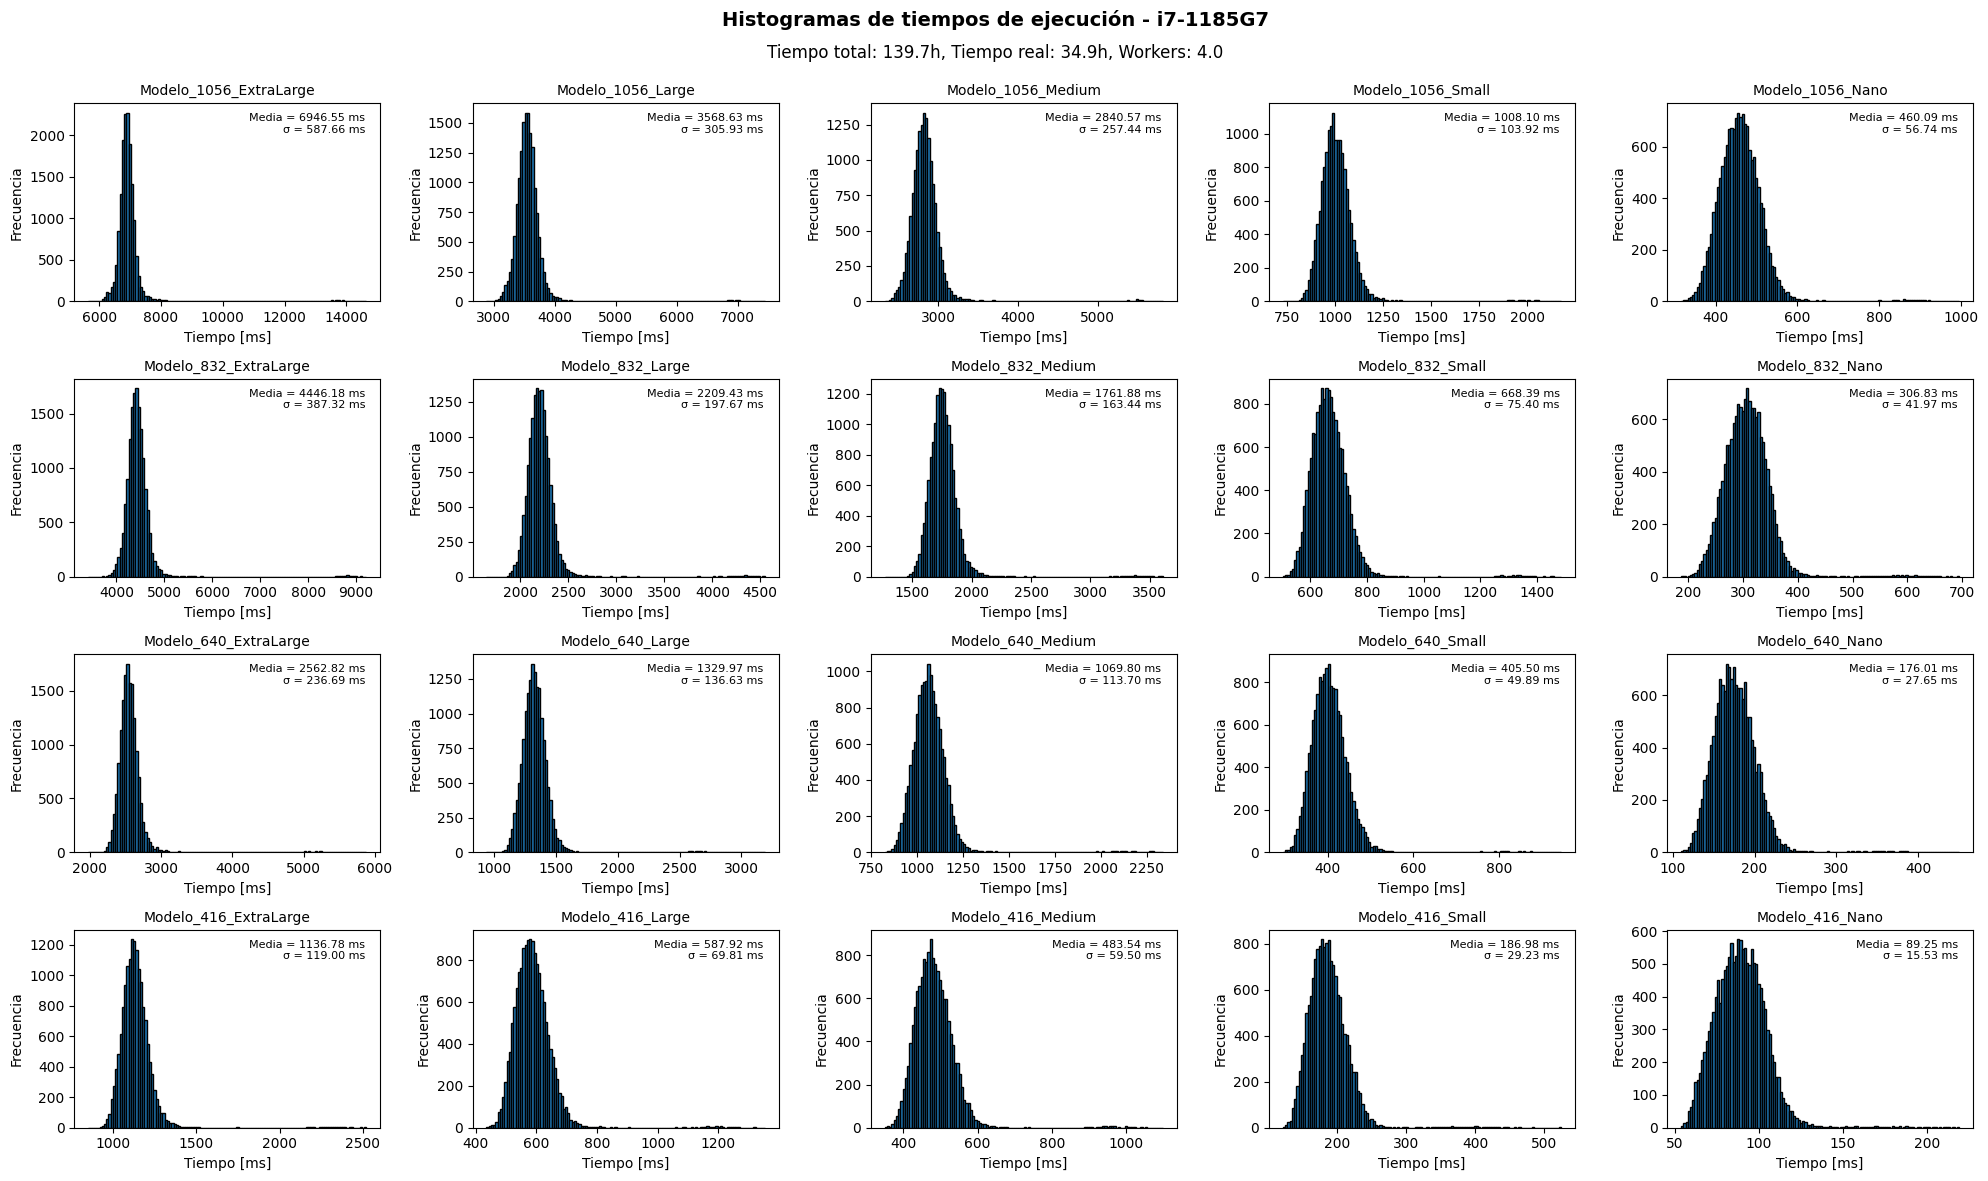

Para el dispositivo i9-11900k, se tienen los siguientes tiempos de ejecucion:



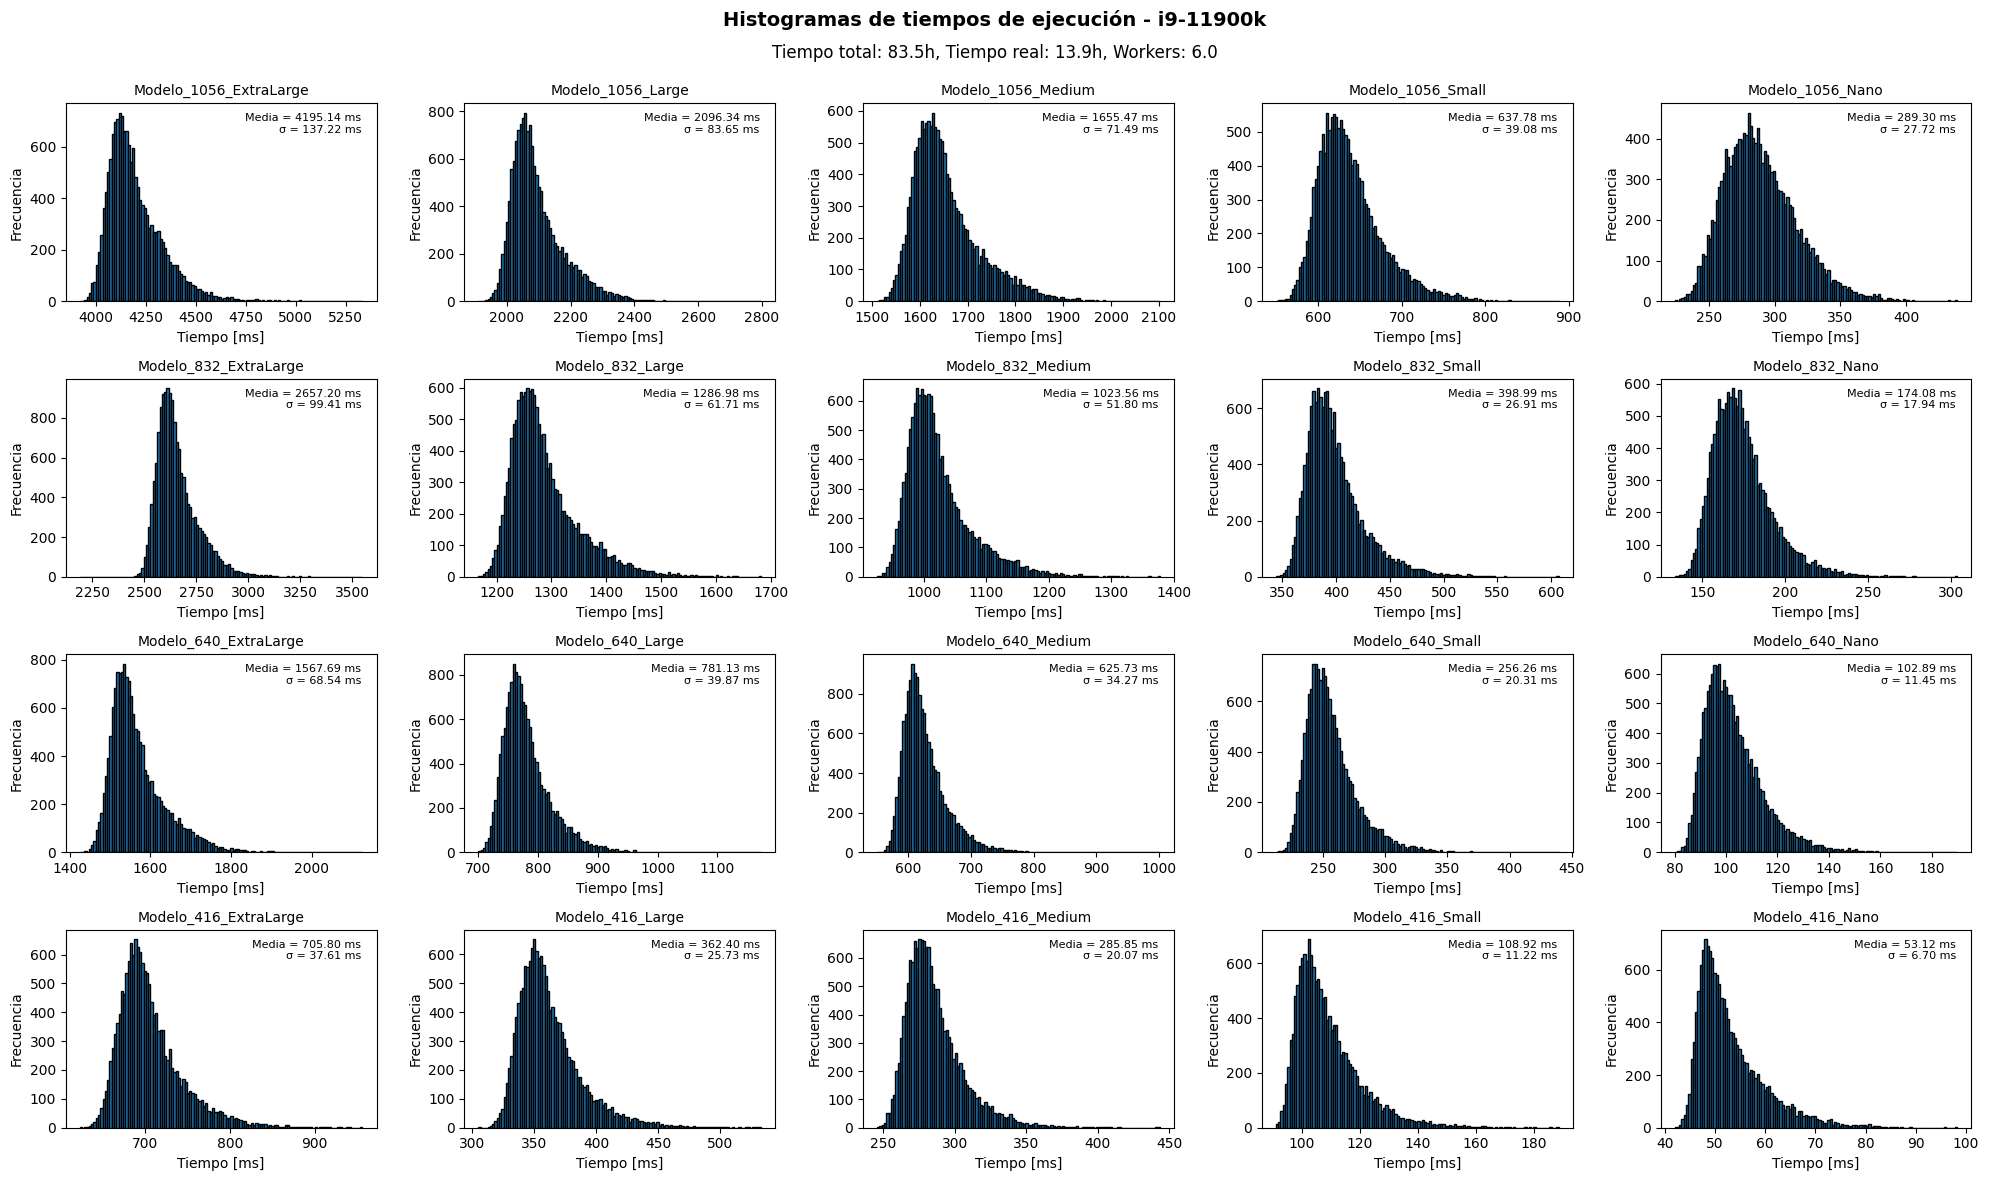

Para el dispositivo RaspberryPi5, se tienen los siguientes tiempos de ejecucion:



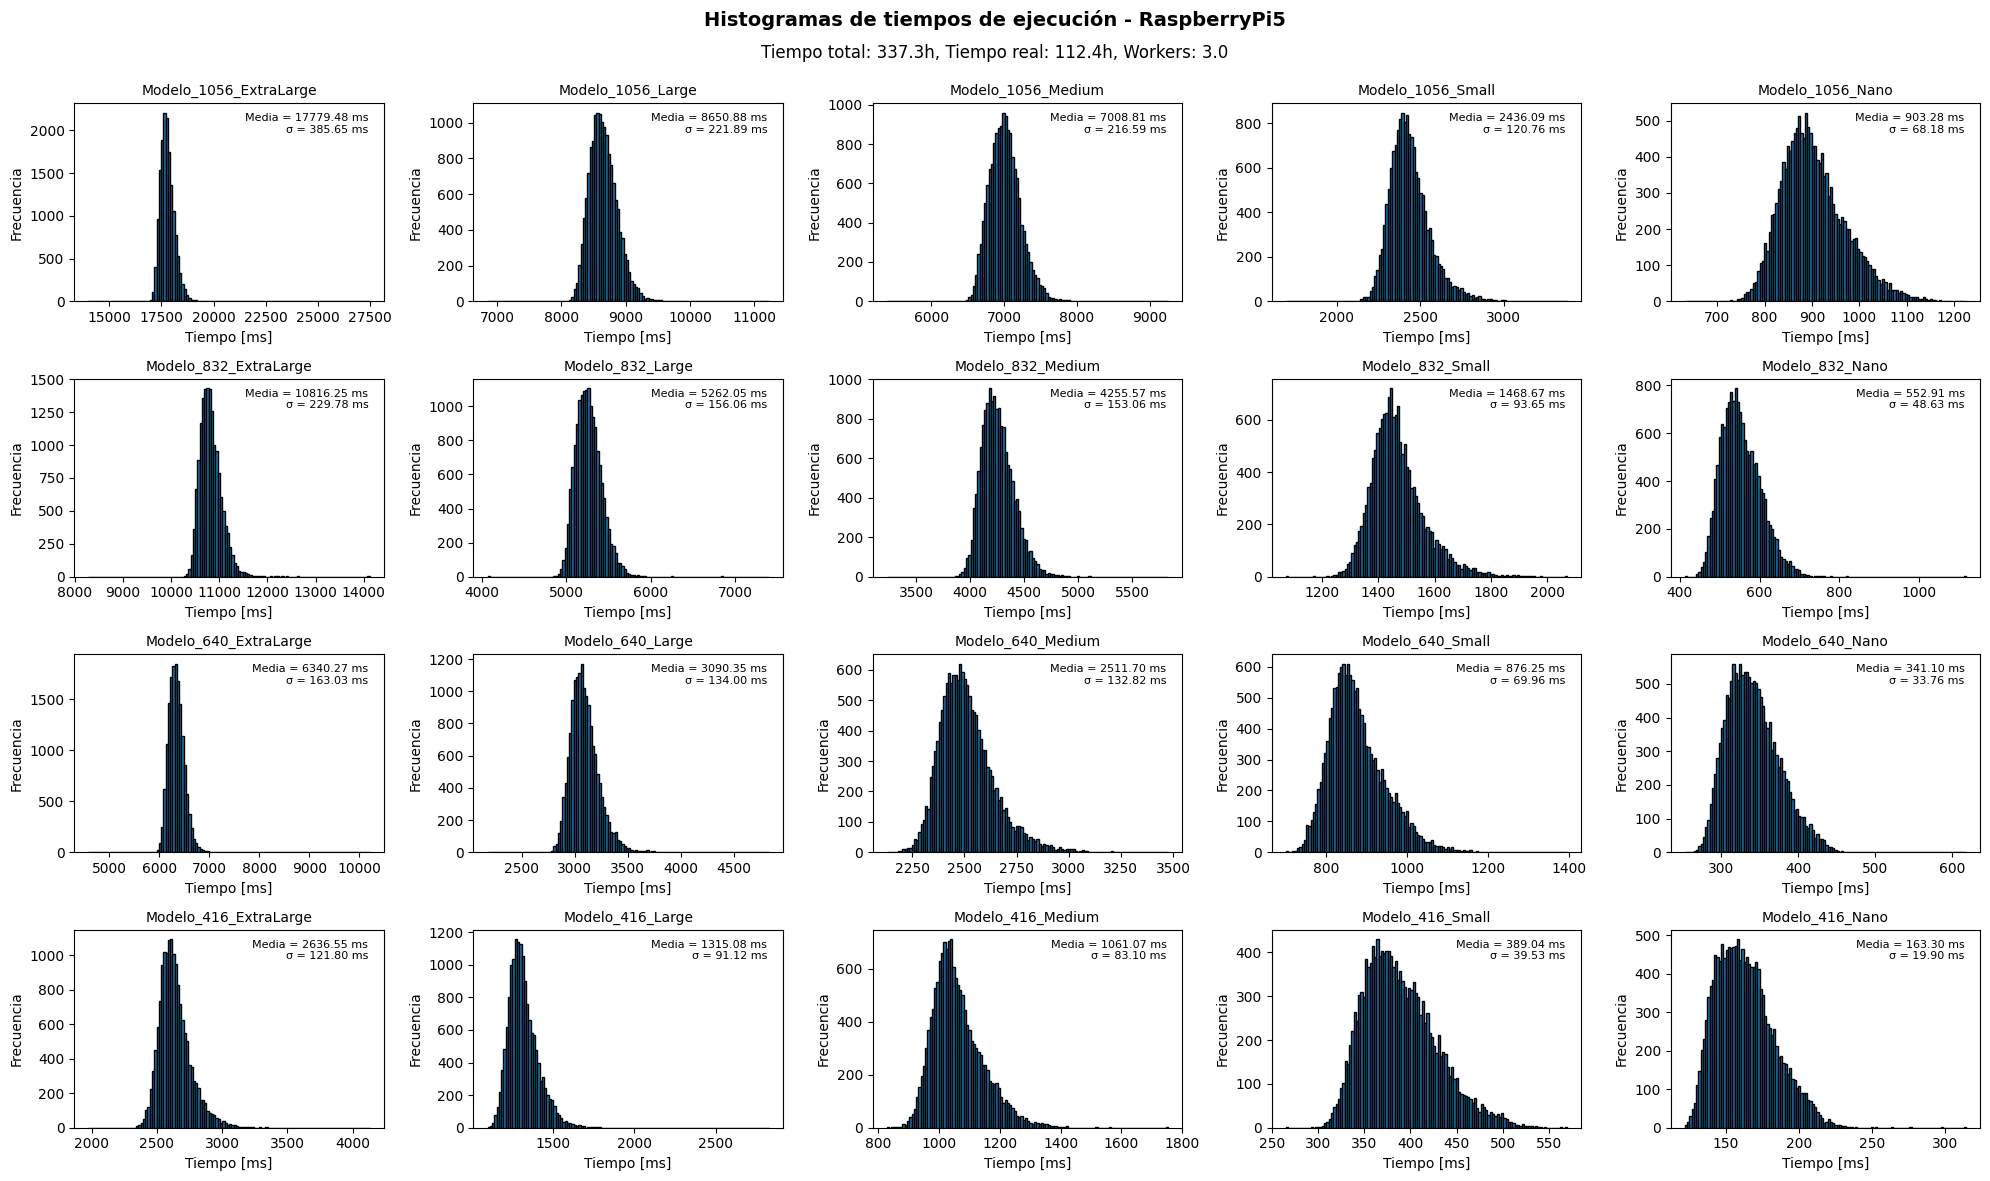

Para el dispositivo RTX4090, se tienen los siguientes tiempos de ejecucion:



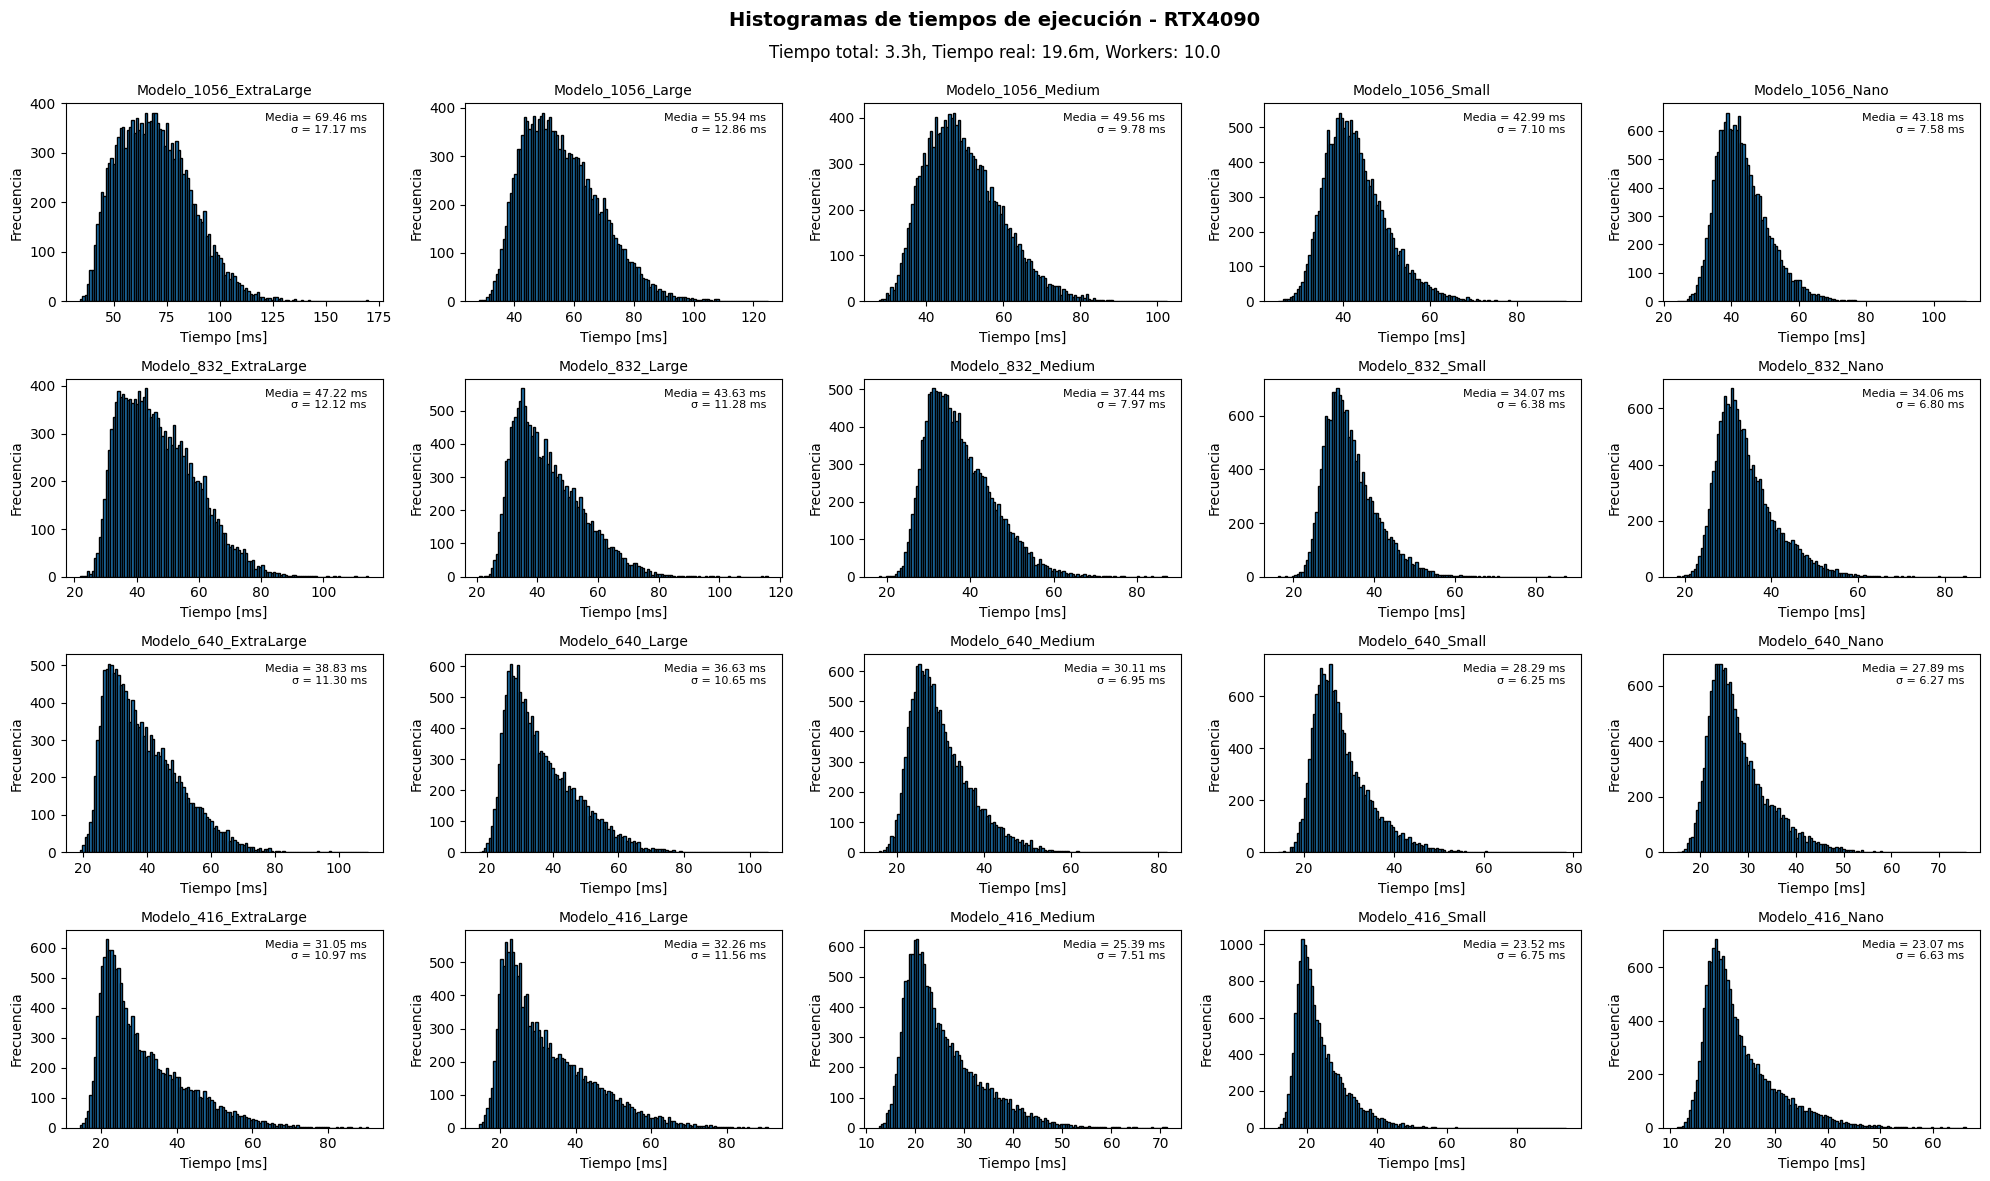

Para el dispositivo RTXA4000, se tienen los siguientes tiempos de ejecucion:



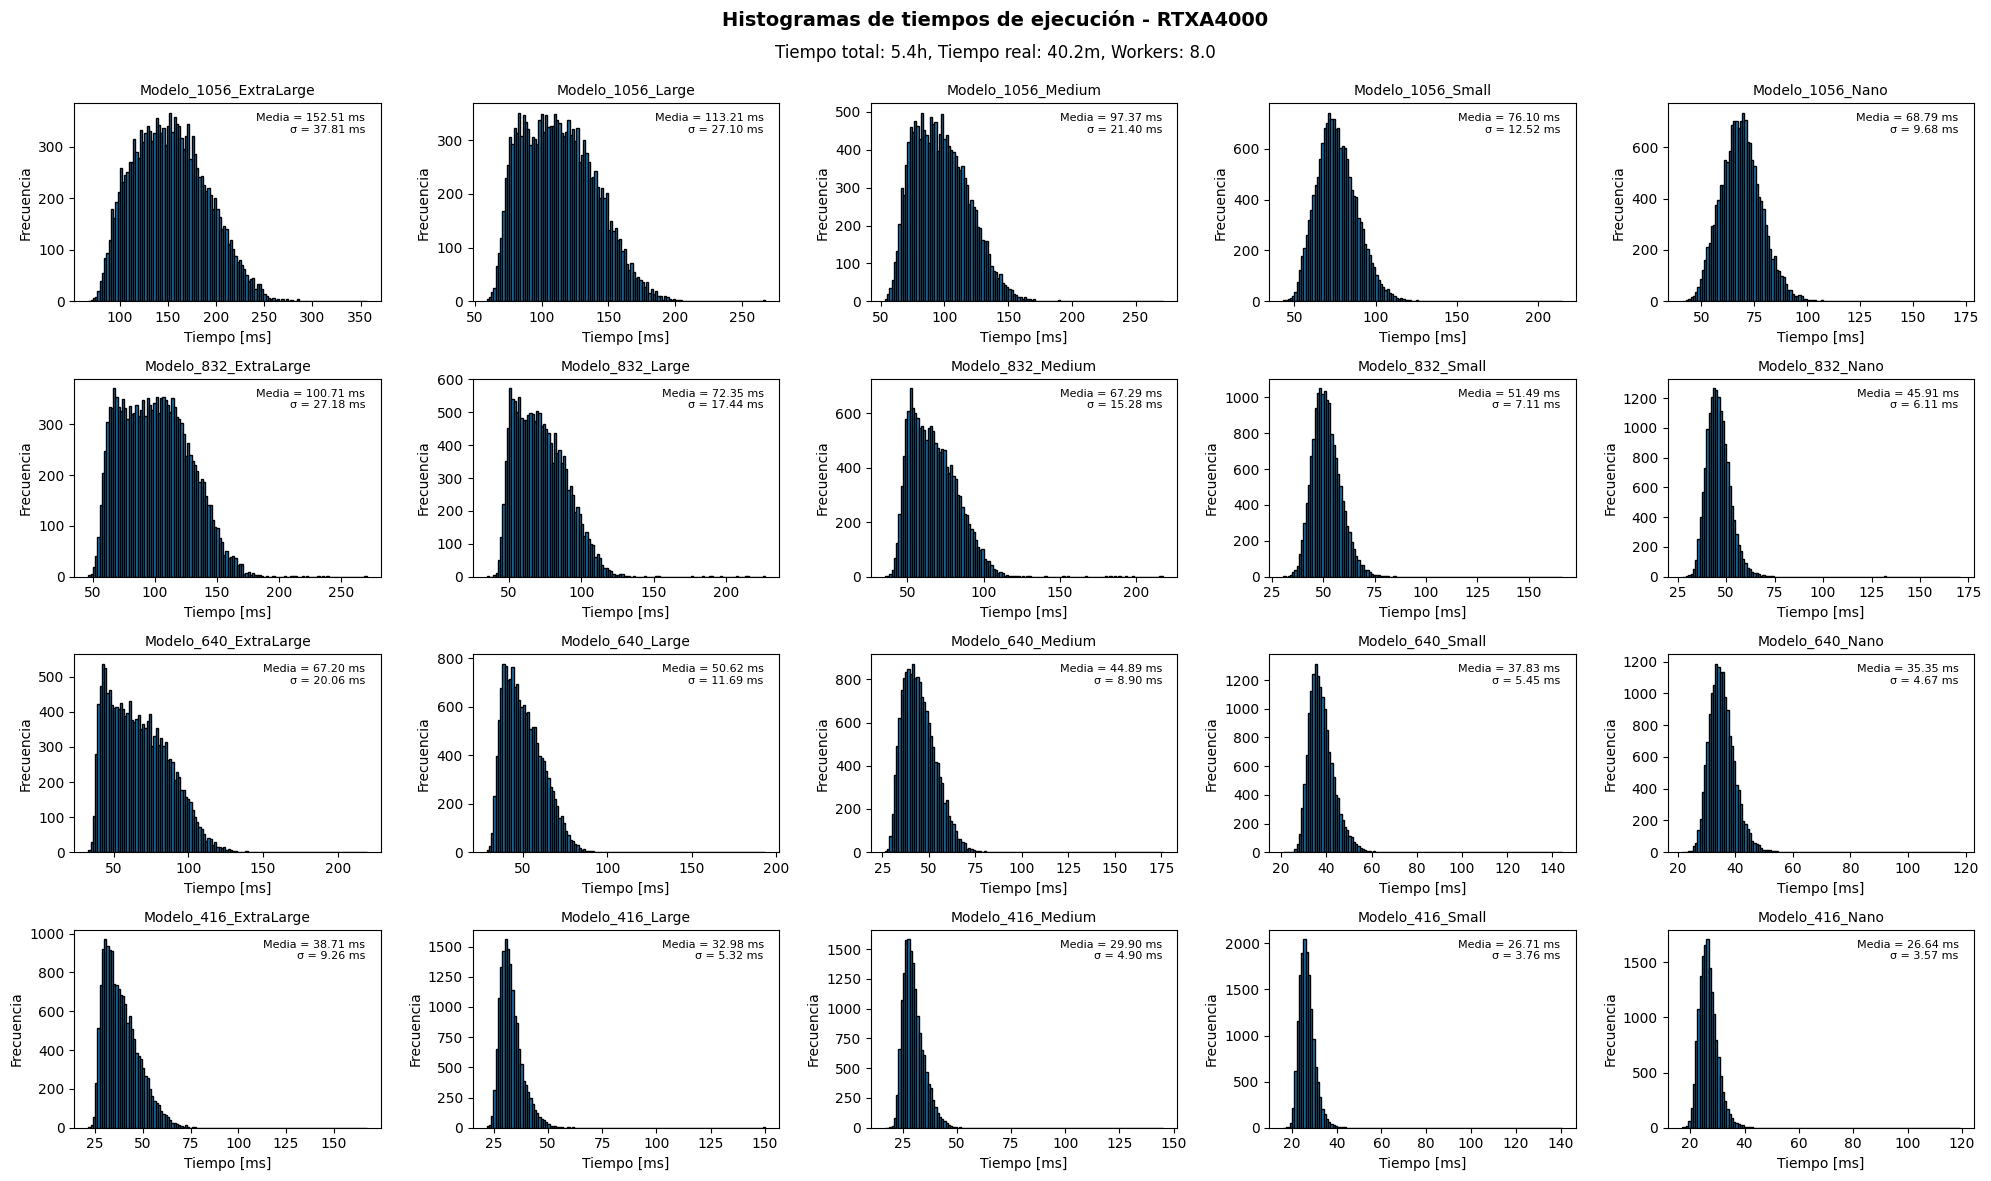

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion:



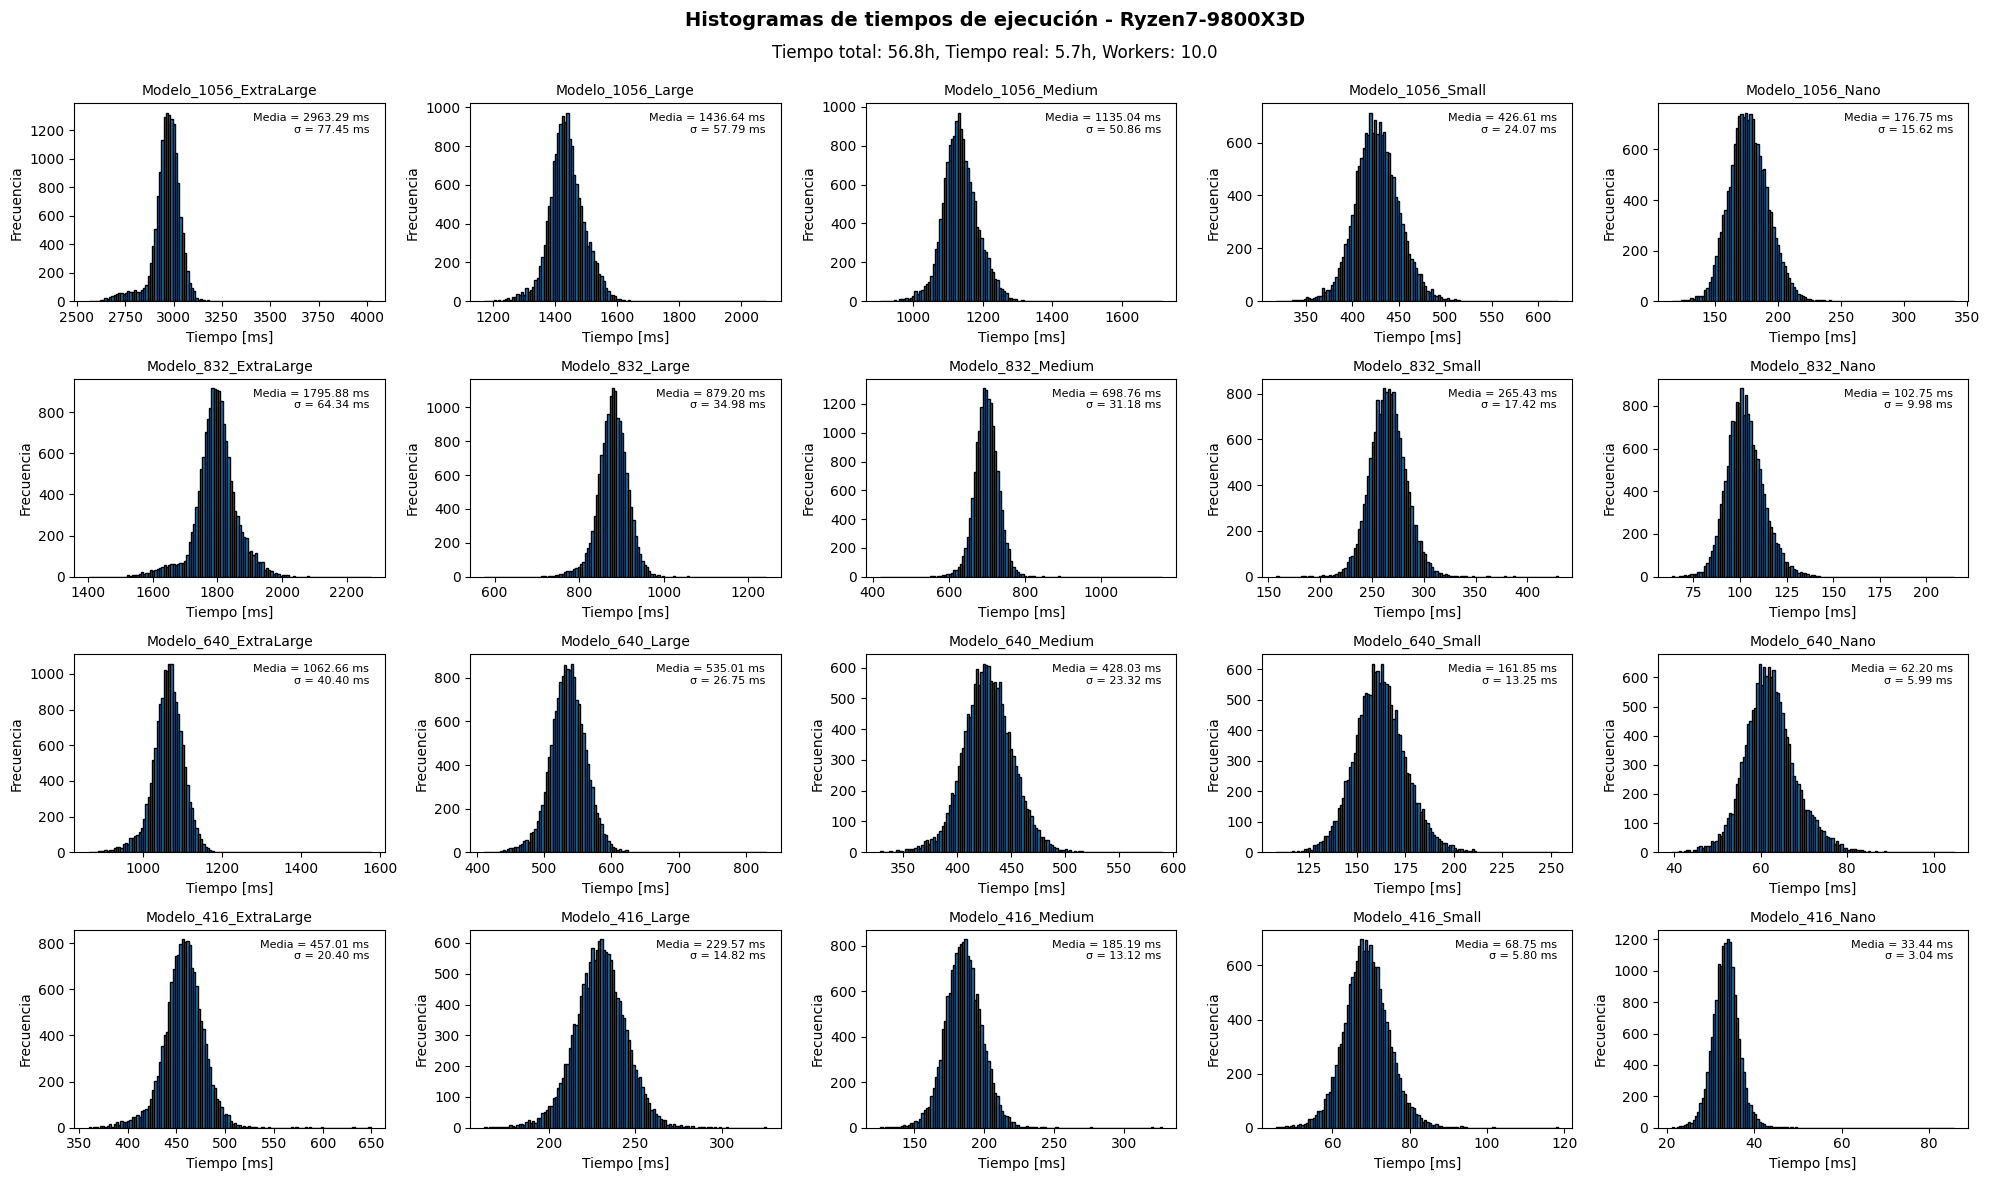

In [ ]:
# ---------------- Variables -------------------------------------------------------------------------------
type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]                                             # Lista con los tipos de modelos usados
size_order = [1056, 832, 640, 416]                                                                          # Lista con los tamaños de los modelos usados                      
Total_Registros = 0                                                                                         # Variable que contiene el total de registros procesados           

Dispositivos = {}                                                                                           # Diccionario que contiene los resultados de los diferentes dispositivos
Resultados_Modelos = {}                                                                                     # Diccionario que contiene los resultados de los diferentes modelos promediando por los dispositivos ejecutados

# ---------------- Extraccion de resultados por dispositivo ------------------------------------------------

Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Clasificacion"))                   # Ruta de los archivos de resultados de clasificacion
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]   # Lista de archivos de resultados de clasificacion
Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))                                                # Ruta de salida de los archivos generados

for file in Ruta_Archivos:                                                  # Iterar sobre cada archivo de resultados de clasificacion
    Resultados_Dispositivo = Clasification_Results(file)                    # Obtener los resultados de clasificacion para el dispositivo actual

    for dispositivo, modelos in Resultados_Dispositivo.items():             # Agregar el numero de cores y tiempo total de ejecucion para cada dispositivo
        Resultados_Dispositivo[dispositivo].update({
            'Cores':float(file.split("_workers")[0].split("_")[-1]),
            'Total time [ms]':0})

        for modelo, resultados in modelos.items():                                          # Buscar en cada modelo los tiempos de ejecucion
            if (modelo != 'Cores' and modelo != 'Total time [ms]'):
                for value in resultados['Speed']:                       
                    Resultados_Dispositivo[dispositivo]['Total time [ms]'] += value         # Sumar los tiempos de ejecucion de cada modelo
                
    Dispositivos.update(Resultados_Dispositivo)                                             # Actualizar el diccionario de dispositivos con los resultados de clasificacion

# ---------------- Concatenando resultados por modelo ------------------------------------------------------

for modelo, Resultados in next(iter(Dispositivos.values())).items():        # Obtener todos los modelos del primer dispositivo, y inicializar sus listas de resultados
    if (modelo != 'Cores' and modelo != 'Total time [ms]'):
        Resultados_Modelos[modelo] = {
            'Embarcacion': [],
            'Falso_Negativo':[],
            'Falso_Positivo':[],
            'No_Embarcacion':[],
            'Probs':[]
        }
        # Sumar el total de registros procesados (Util para normalizar resultados) 
        Total_Registros=Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']

for _, Modelos in Dispositivos.items():                                     # Iterar sobre cada dispositivo y sus modelos    
    for modelo, resultados in Modelos.items():                              # Iterar sobre cada modelo y sus resultados
        if (modelo != 'Cores' and modelo != 'Total time [ms]'):             # Ignorar las entradas que no son modelos
        
            for resultado, Valor in resultados.items():                     # Iterar sobre cada resultado y su valor
                if(resultado == 'Probs'):                                   # Si el resultado es una lista de probabilidades, agregar cada probabilidad a la lista correspondiente
                    for prob in Valor:
                        Resultados_Modelos[modelo][resultado].append(prob)
                elif(resultado != 'Speed'):                                 # Descarta el resultado de la velocidad de ejecucion, y agrega los demas resultados (Detecciones de embarcaciones, falsos positivos, etc)
                    Resultados_Modelos[modelo][resultado].append(Valor)     
            
# ---------------- Analisis de resultados por modelo -------------------------------------------------------
data = {}                                                                                           # Diccionario auxiliar

for modelo, resultados in Resultados_Modelos.items():                                               # Iterar sobre cada modelo y sus resultados
    match = re.search(r"_(\d+)_([A-Za-z]+)$", modelo)                                               # Extraer el tamaño y tipo del modelo usando expresiones regulares
    if match:                                                                                       # Si se encontró una coincidencia, extraer el tamaño y tipo
        size = int(match.group(1))
        model_type = match.group(2)
    else:                                                                                           # Si no se encontró una coincidencia, asignar valores por defecto
        size = "Desconocido"
        model_type = "Desconocido"

    col_label = (size, model_type)                                                                  # Crear una etiqueta de columna como una tupla (tamaño, tipo)                

    metrics = {                                                                                     # Calcular las métricas de interés y almacenarlas en un diccionario
        "Embarcación":          (stats.mean(resultados["Embarcacion"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Embarcacion"]) * 100 / Total_Registros),

        "No Embarcación":       (stats.mean(resultados["No_Embarcacion"]) * 100 / Total_Registros,
                                stats.stdev(resultados["No_Embarcacion"]) * 100 / Total_Registros),

        "Falso Negativo":       (stats.mean(resultados["Falso_Negativo"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Falso_Negativo"]) * 100 / Total_Registros),

        "Falso Positivo":       (stats.mean(resultados["Falso_Positivo"]) * 100 / Total_Registros,
                                stats.stdev(resultados["Falso_Positivo"]) * 100 / Total_Registros),

        "Probabilidad media":   (stats.mean(resultados["Probs"]) if resultados["Probs"] else None,
                                stats.stdev(resultados["Probs"]) if len(resultados["Probs"]) > 1 else None),
    }

    for metric, (mean, std) in metrics.items():             # Iterar sobre cada métrica y su valor (media y desviación estándar)
        if metric not in data:                              # Si la métrica no está en el diccionario auxiliar, inicializarla
            data[metric] = {}
        data[metric][col_label] = f"{mean:.2f}±{std:.2f}"   # Almacenar la métrica formateada como "media±desviación estándar" en el diccionario auxiliar

df = pd.DataFrame(data).T                                                           # Crear DataFrame
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Resolución", "Tipo"])    # Asignar MultiIndex a las columnas

df = df.sort_index(axis=1, level=["Resolución", "Tipo"], ascending=[False, True])   # Ordenar por resolución descendente y tipo ascendente
ordered_columns = pd.MultiIndex.from_product(                                       # Aplicar orden definido manualmente (sin usar axis=)
    [
        [s for s in size_order if s in df.columns.get_level_values("Resolución")],
        [t for t in type_order if t in df.columns.get_level_values("Tipo")]
    ],
    names=["Resolución", "Tipo"]
)
ordered_columns = [col for col in ordered_columns if col in df.columns]             # Filtramos solo las columnas que realmente existen
df = df.reindex(columns=ordered_columns)                                            # Reindexamos columnas con el nuevo orden                             

# Mostrar tabla
print("\nMatriz de confusión promedio (promediada en todos los dispositivos):\n")
print(df)

# ---------------- Analisis de resultados por dispositivo - Tiempo de ejecucion ----------------------------
data = {}                                                                                           # Diccionario auxiliar

for dispositivo, modelos in Dispositivos.items():                                                   # Iterar sobre cada dispositivo y sus resultados
    data[dispositivo] = {}                                                                          # Inicializar el diccionario para el dispositivo actual
    
    for modelo, resultados in modelos.items():                                                      # Iterar sobre cada modelo y sus resultados
        if modelo not in ('Cores', 'Total time [ms]'):                                              # Ignorar las entradas que no son modelos
            
            match = re.search(r"_(\d+)_([A-Za-z]+)$", modelo)                                       # Extraer el tamaño y tipo del modelo usando expresiones regulares
            if match:                                                                               # Si se encontró una coincidencia, extraer el tamaño y tipo
                size = int(match.group(1))
                model_type = match.group(2)
            else:                                                                                   # Si no se encontró una coincidencia, asignar valores por defecto
                size = "Desconocido"
                model_type = "Desconocido"

            col_label = (size, model_type)                                                          # Crear una etiqueta de columna como una tupla (tamaño, tipo)

            mean = stats.mean(resultados["Speed"])                                                  # Calcular la media de los tiempos de ejecución 
            std = stats.stdev(resultados["Speed"]) if len(resultados["Speed"]) > 1 else 0           # Calcular la desviación estándar de los tiempos de ejecución (0 si solo hay un valor)    

            data[dispositivo][col_label] = f"{mean:.2f}±{std:.2f}"                                  # Almacenar la métrica formateada como "media±desviación estándar" en el diccionario auxiliar

df = pd.DataFrame.from_dict(data, orient="index")                                   # Crear DataFrame
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Resolución", "Tipo"])    # Asignar MultiIndex a las columnas

df = df.sort_index(axis=1, level=["Resolución", "Tipo"], ascending=[False, True])   # Ordenar por resolución descendente y tipo ascendente
ordered_columns = pd.MultiIndex.from_product(                                       # Aplicar orden definido manualmente (sin usar axis=)
    [
        [s for s in size_order if s in df.columns.get_level_values("Resolución")],
        [t for t in type_order if t in df.columns.get_level_values("Tipo")]
    ],
    names=["Resolución", "Tipo"]
)
ordered_columns = [col for col in ordered_columns if col in df.columns]             # Filtramos solo las columnas que realmente existen
df = df.reindex(columns=ordered_columns)                                            # Reindexamos columnas con el nuevo orden   

# Mostrar tabla
print("\nTiempos de ejecución promedio por dispositivo (ms):\n")
print(df)

# ---------------- Imprimir Distribuciones estadisticas ----------------------------------------------------

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida, "Ejecucion_Clasificacion_Dispositivo.pdf"))) as pdf:   # Crear un archivo PDF para guardar las figuras
    for dispositivo, modelos in Dispositivos.items():                                                           # Cada dispositivo representa una figura/pagina nueva
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion:\n")

        # --- Extraer Cores y tiempo total del mismo diccionario ---
        cores = modelos.get("Cores", 1)
        total_ms = modelos.get("Total time [ms]", 0)

        # --- Ordenar modelos según resolución y tipo ---
        modelos_ordenados = []
        for size in size_order:
            for tipo in type_order:
                for modelo in modelos.keys():
                    if re.search(fr"_{size}_{tipo}$", modelo):
                        modelos_ordenados.append(modelo)

        # Crear figura
        fig, axs = plt.subplots(4, 5, figsize=(20, 12))
        axs = axs.flatten()

        for i, modelo in enumerate(modelos_ordenados):
            if i >= len(axs):  # Limitar a 20 plots por dispositivo
                break

            resultados = modelos[modelo]    
            if "Speed" not in resultados:
                continue

            datos = resultados["Speed"]
            if len(datos) == 0:
                continue

            media = stats.mean(datos)
            sigma = stats.stdev(datos) if len(datos) > 1 else 0

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        # Desactivar los ejes vacíos
        for j in range(i + 1, len(axs)):
            axs[j].axis("off")

        # --- Calcular tiempos totales y reales ---
        tiempo_total = total_ms / (1000 * 60 * 60)
        tiempo_total_str = f"{round(tiempo_total, 1)}h"

        tiempo_real = total_ms / (1000 * 60 * 60 * cores)
        tiempo_real_str = f"{round(tiempo_real * 60, 1)}m" if tiempo_real < 1 else f"{round(tiempo_real, 1)}h"

        # --- Título general ---
        plt.suptitle(
            f"Histogramas de tiempos de ejecución - {dispositivo}",
            fontsize=14, fontweight="bold"
        )
        fig.text(
            0.5, 0.94,
            f"Tiempo total: {tiempo_total_str}, Tiempo real: {tiempo_real_str}, Workers: {cores}",
            ha="center", fontsize=12
        )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        pdf.savefig(fig)
        plt.close(fig)


Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)
Para el modelo Modelo_1056_ExtraLarge:
Embarcaciones: 13.518809537667577±0.003005632847298308%
Sin embarcaciones: 79.71596531051743±0.0%
Falso Negativo: 0.10476689366160294±0.0%
Falso Positivo: 7.481132258502609±0.006011265694596616%
IoU medio: 51.80754917082364±37.00339554346541%

Para el modelo Modelo_832_ExtraLarge:
Embarcaciones: 13.322856643967173±0.0%
Sin embarcaciones: 79.66940224666783±0.0%
Falso Negativo: 0.1105872766428031±0.0%
Falso Positivo: 7.333682556312206±0.0%
IoU medio: 52.171782737174276±37.32286937526365%

Para el modelo Modelo_640_ExtraLarge:
Embarcaciones: 13.607085346215781±0.002376161401919929%
Sin embarcaciones: 79.57627611896862±0.0%
Falso Negativo: 0.1862522553984052±0.0%
Falso Positivo: 7.794462875657219±0.002376161401919929%
IoU medio: 51.208307516243146±36.419643506783316%

Para el modelo Modelo_416_ExtraLarge:
Embarcaciones: 12.53128455852395±0.0%
Sin embarcaciones: 79.5

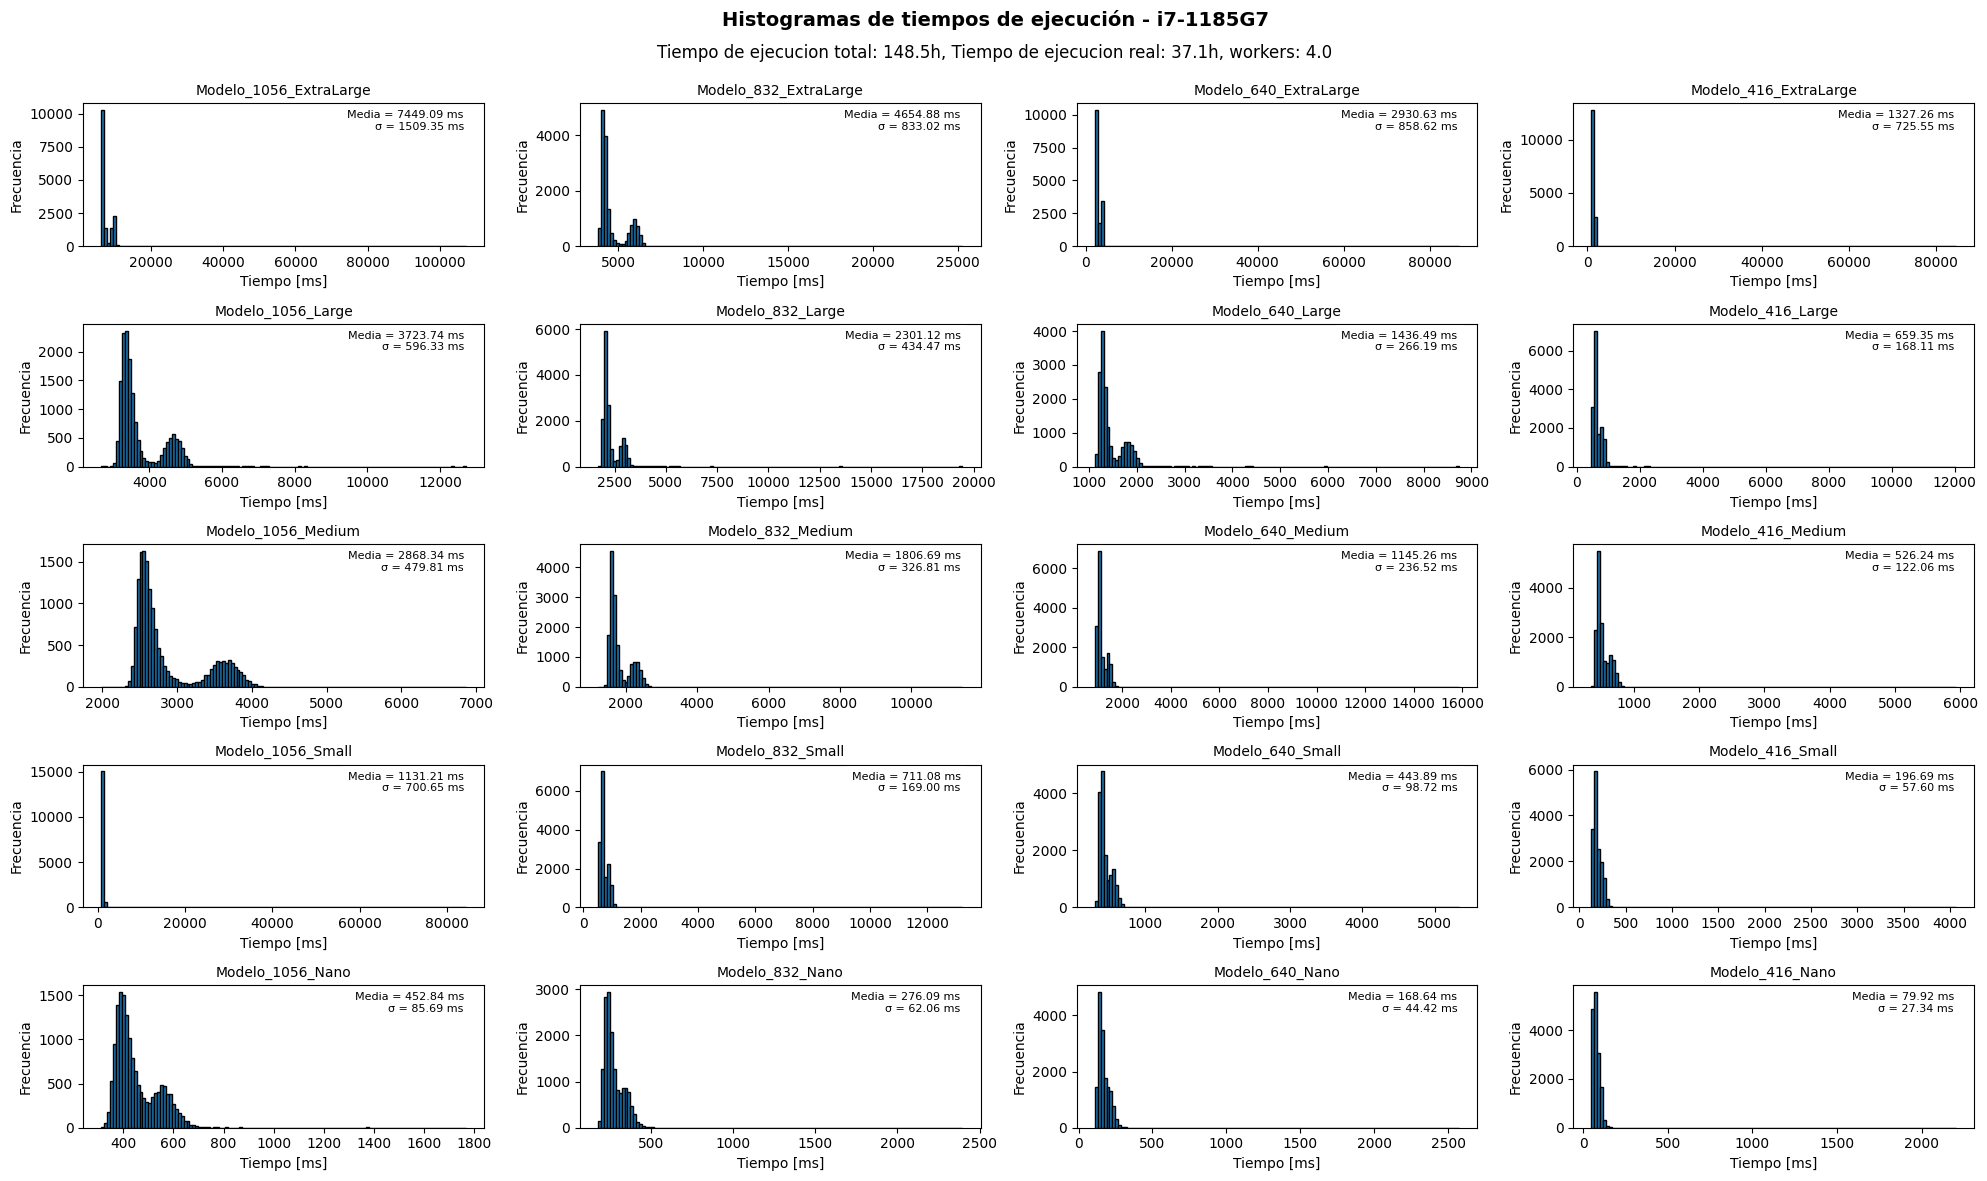

Para el dispositivo i9-11900k, se tienen los siguientes tiempos de ejecucion: 


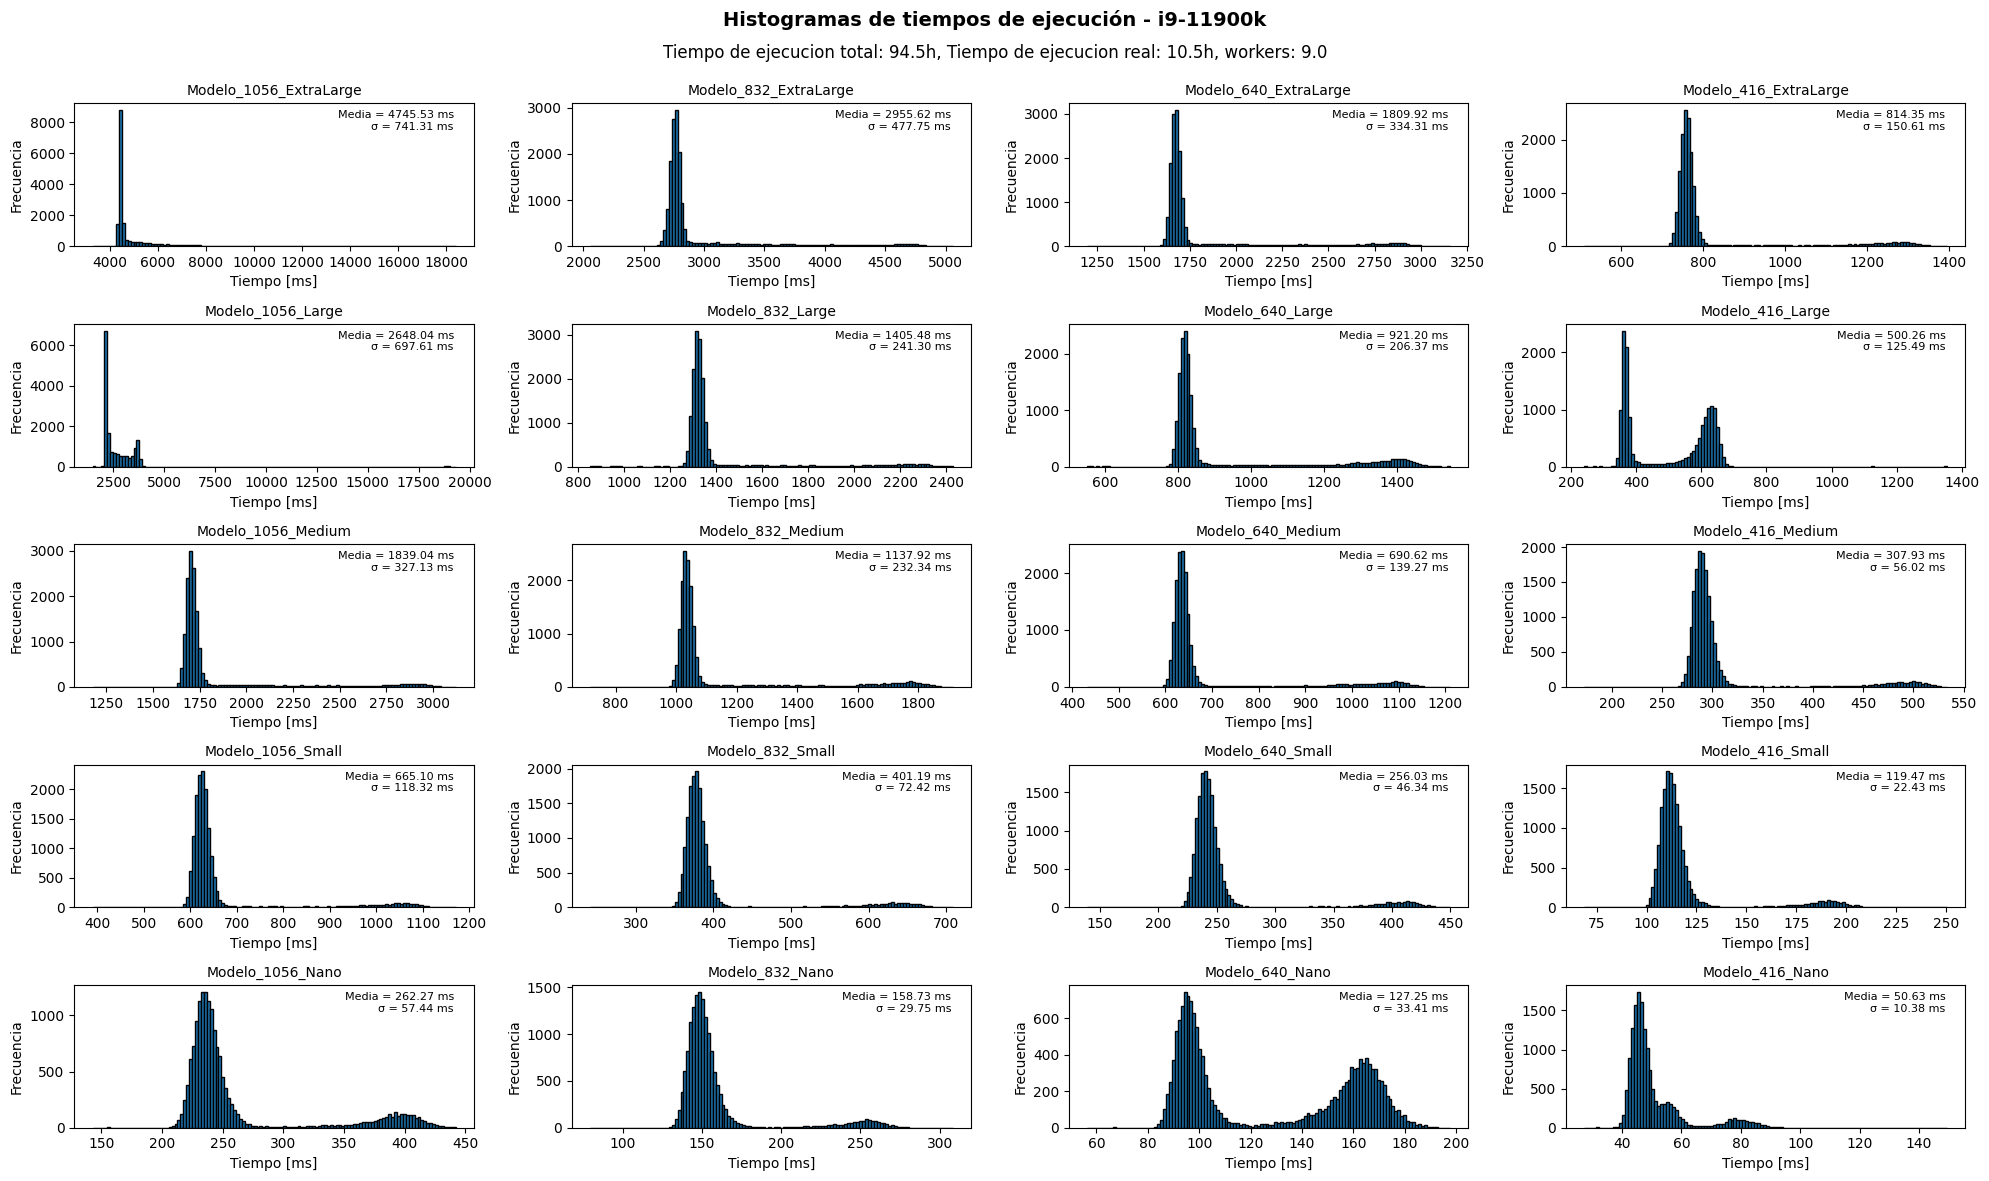

Para el dispositivo RaspberryPi5, se tienen los siguientes tiempos de ejecucion: 


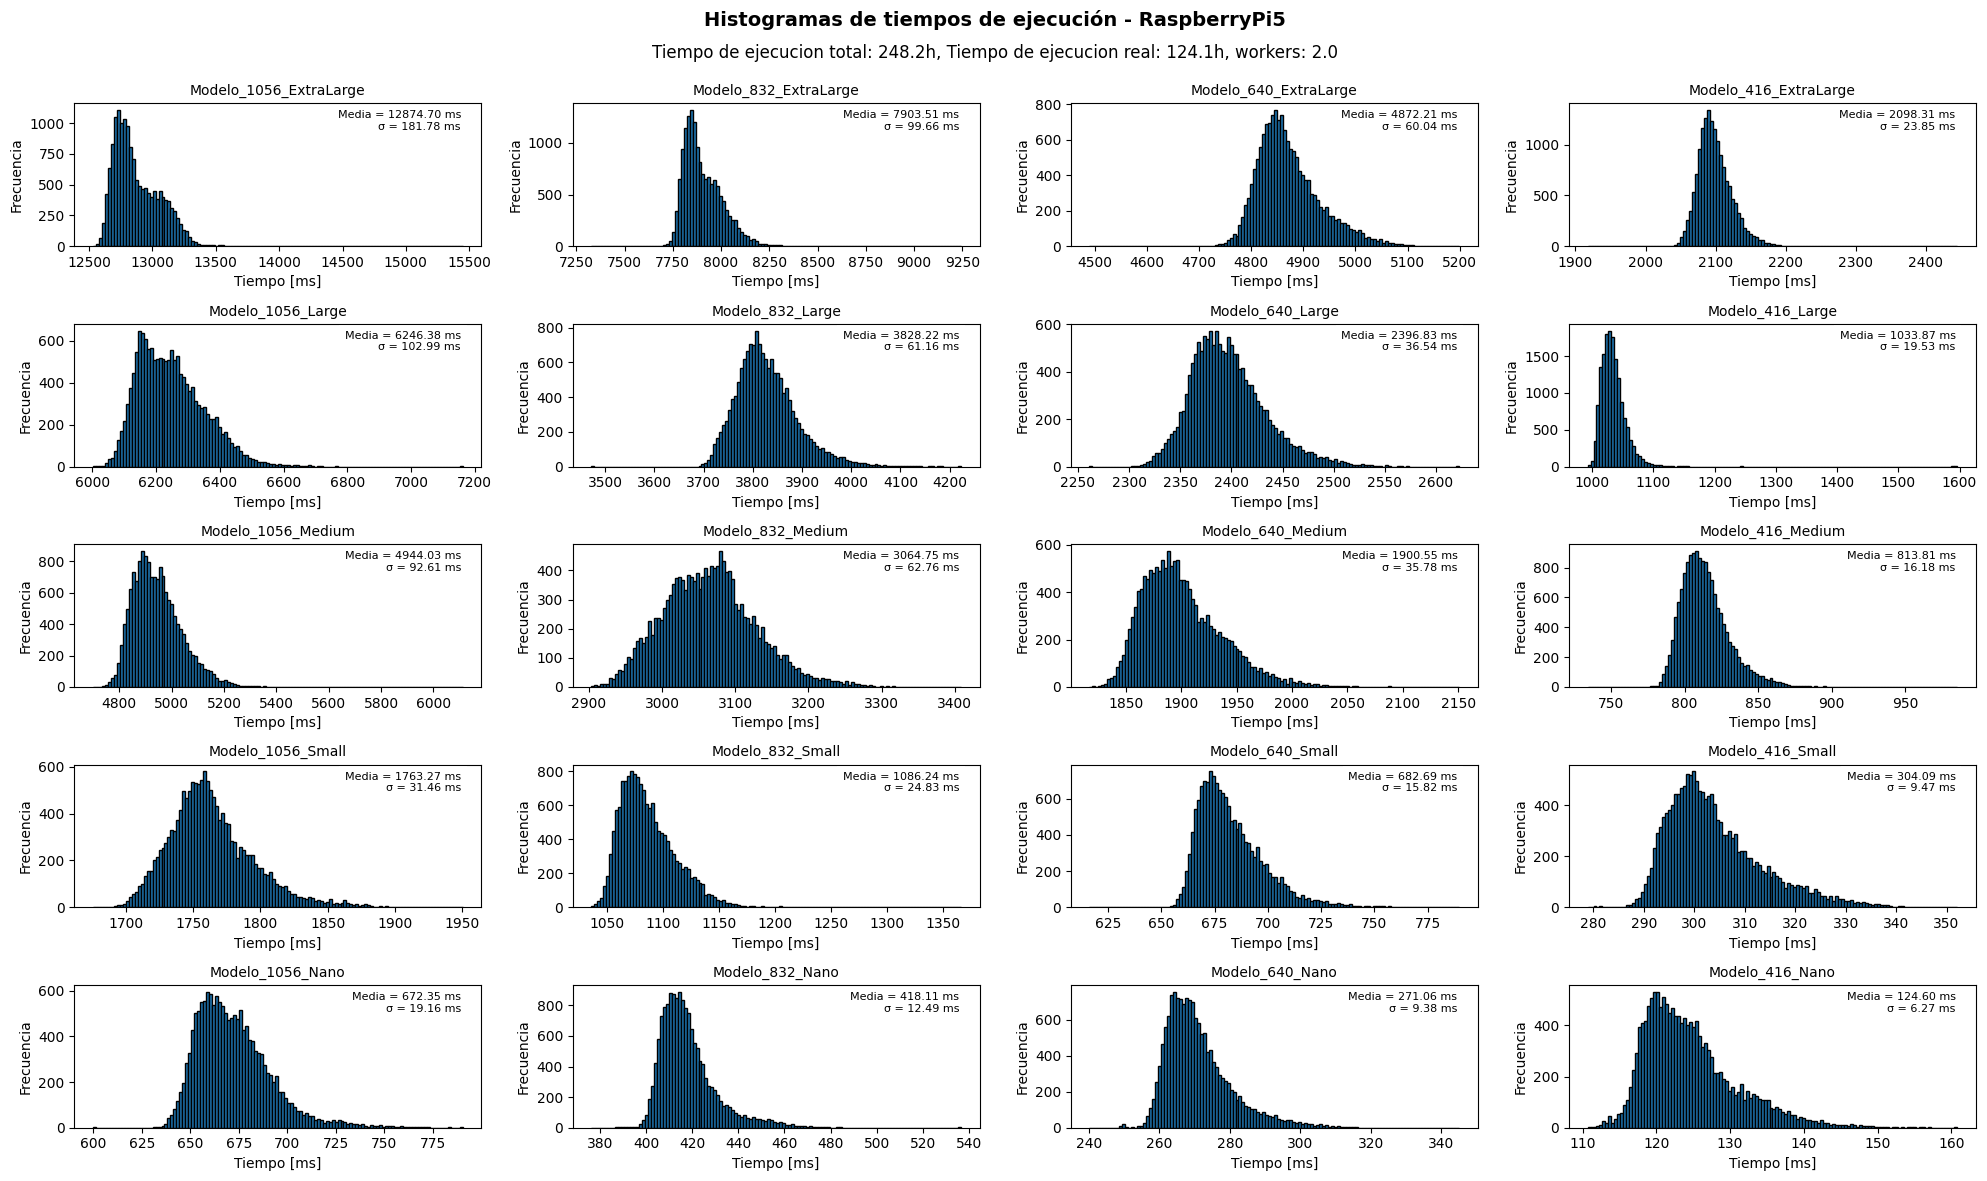

Para el dispositivo RTX4090, se tienen los siguientes tiempos de ejecucion: 


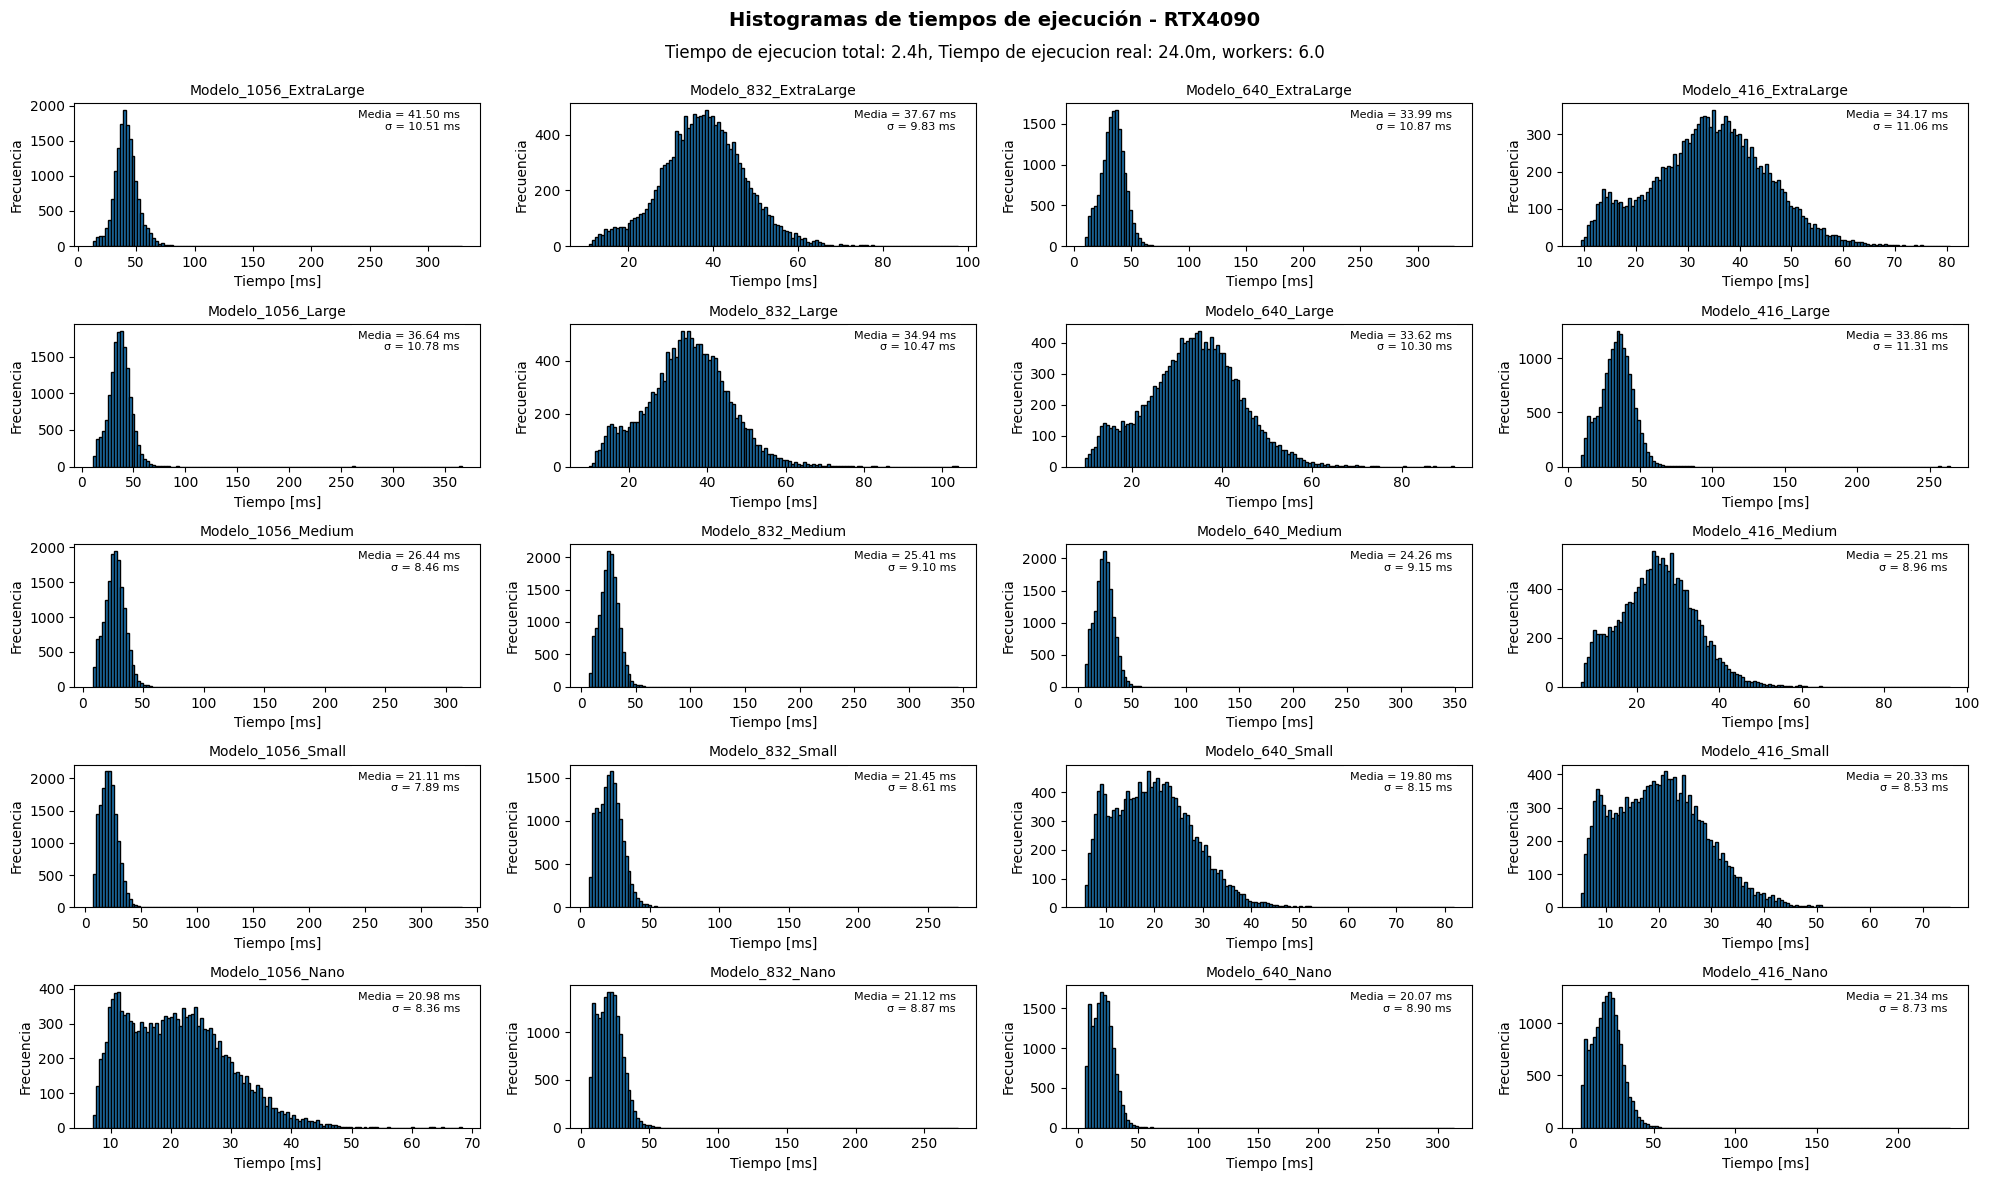

Para el dispositivo RTXA4000, se tienen los siguientes tiempos de ejecucion: 


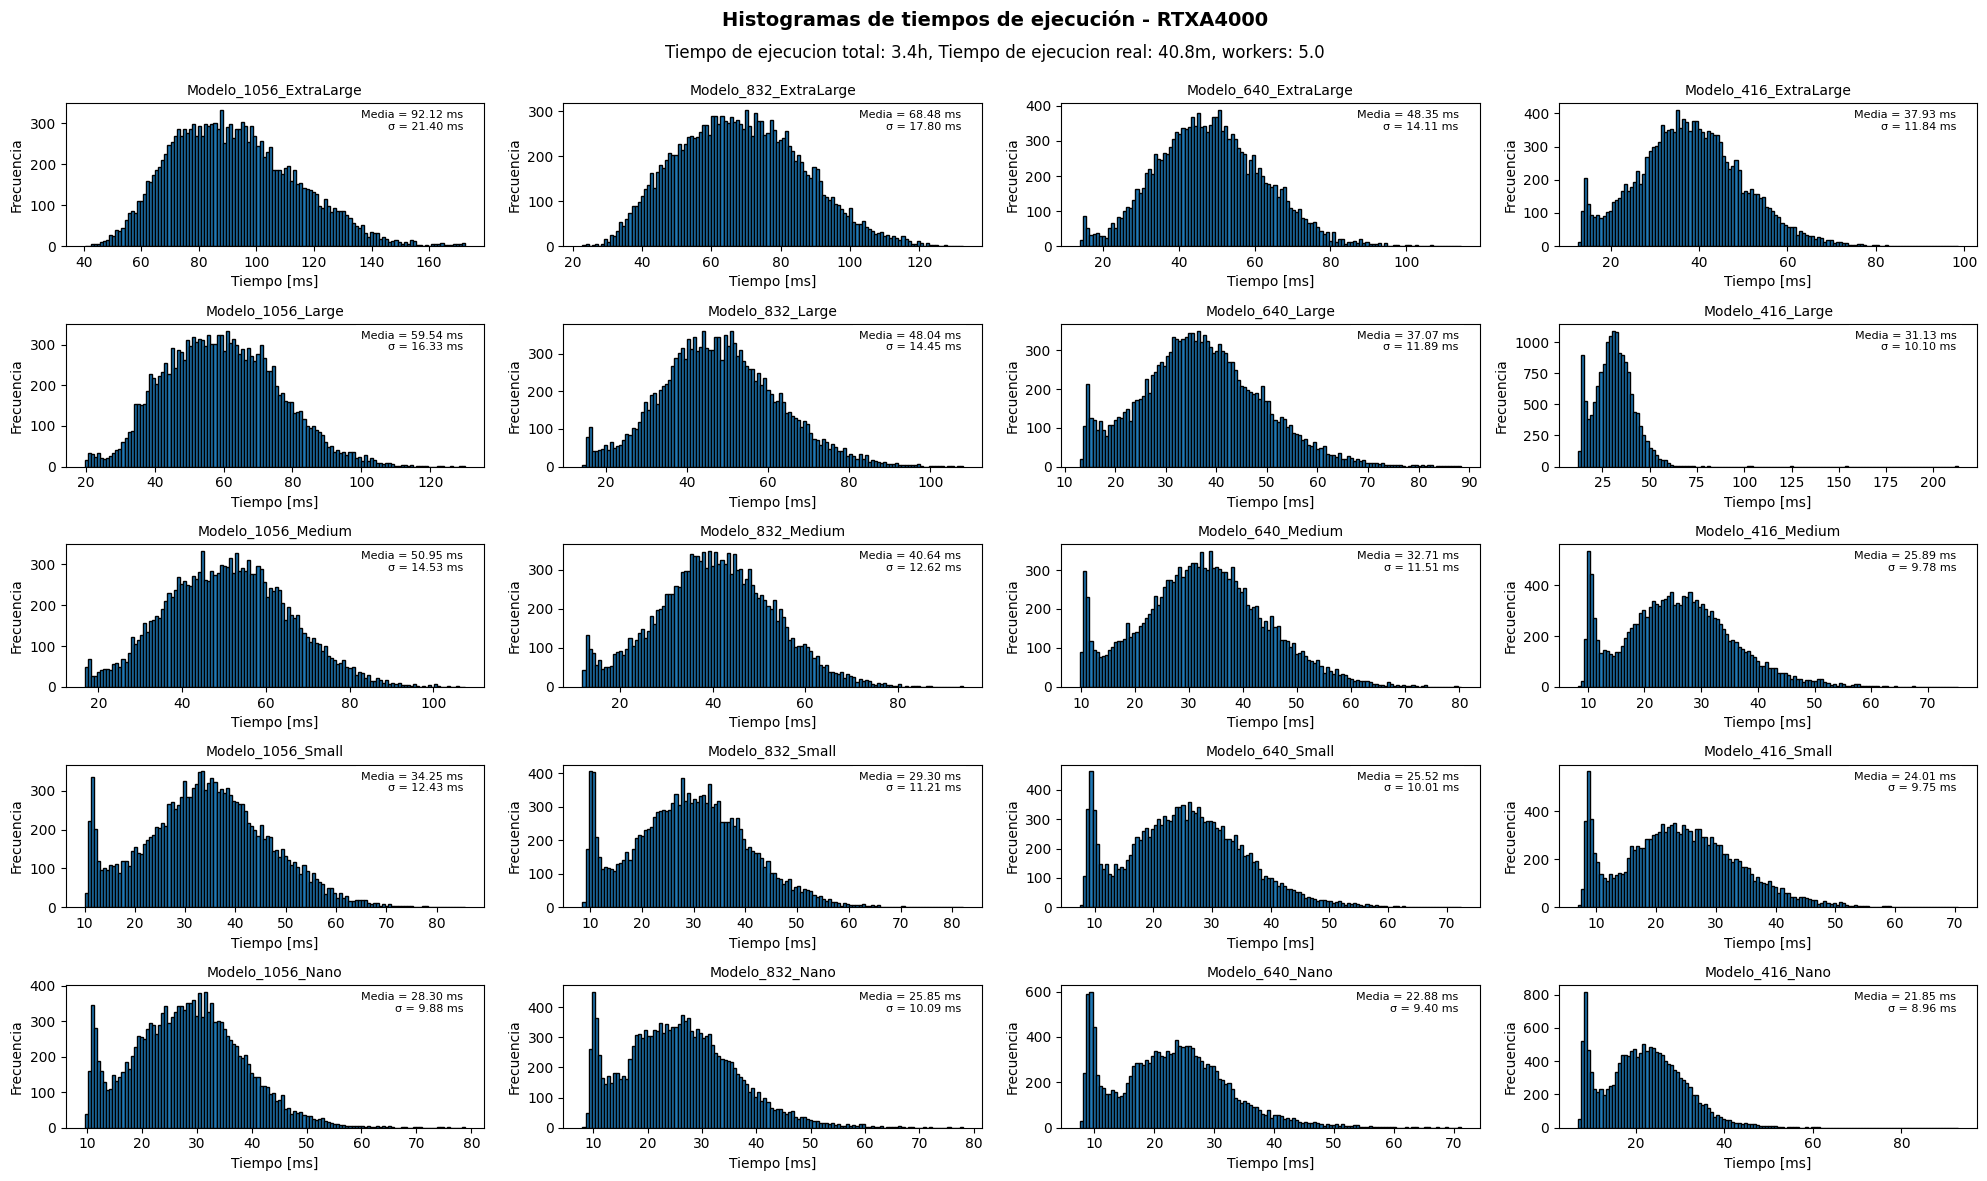

Para el dispositivo Ryzen7-9800X3D, se tienen los siguientes tiempos de ejecucion: 


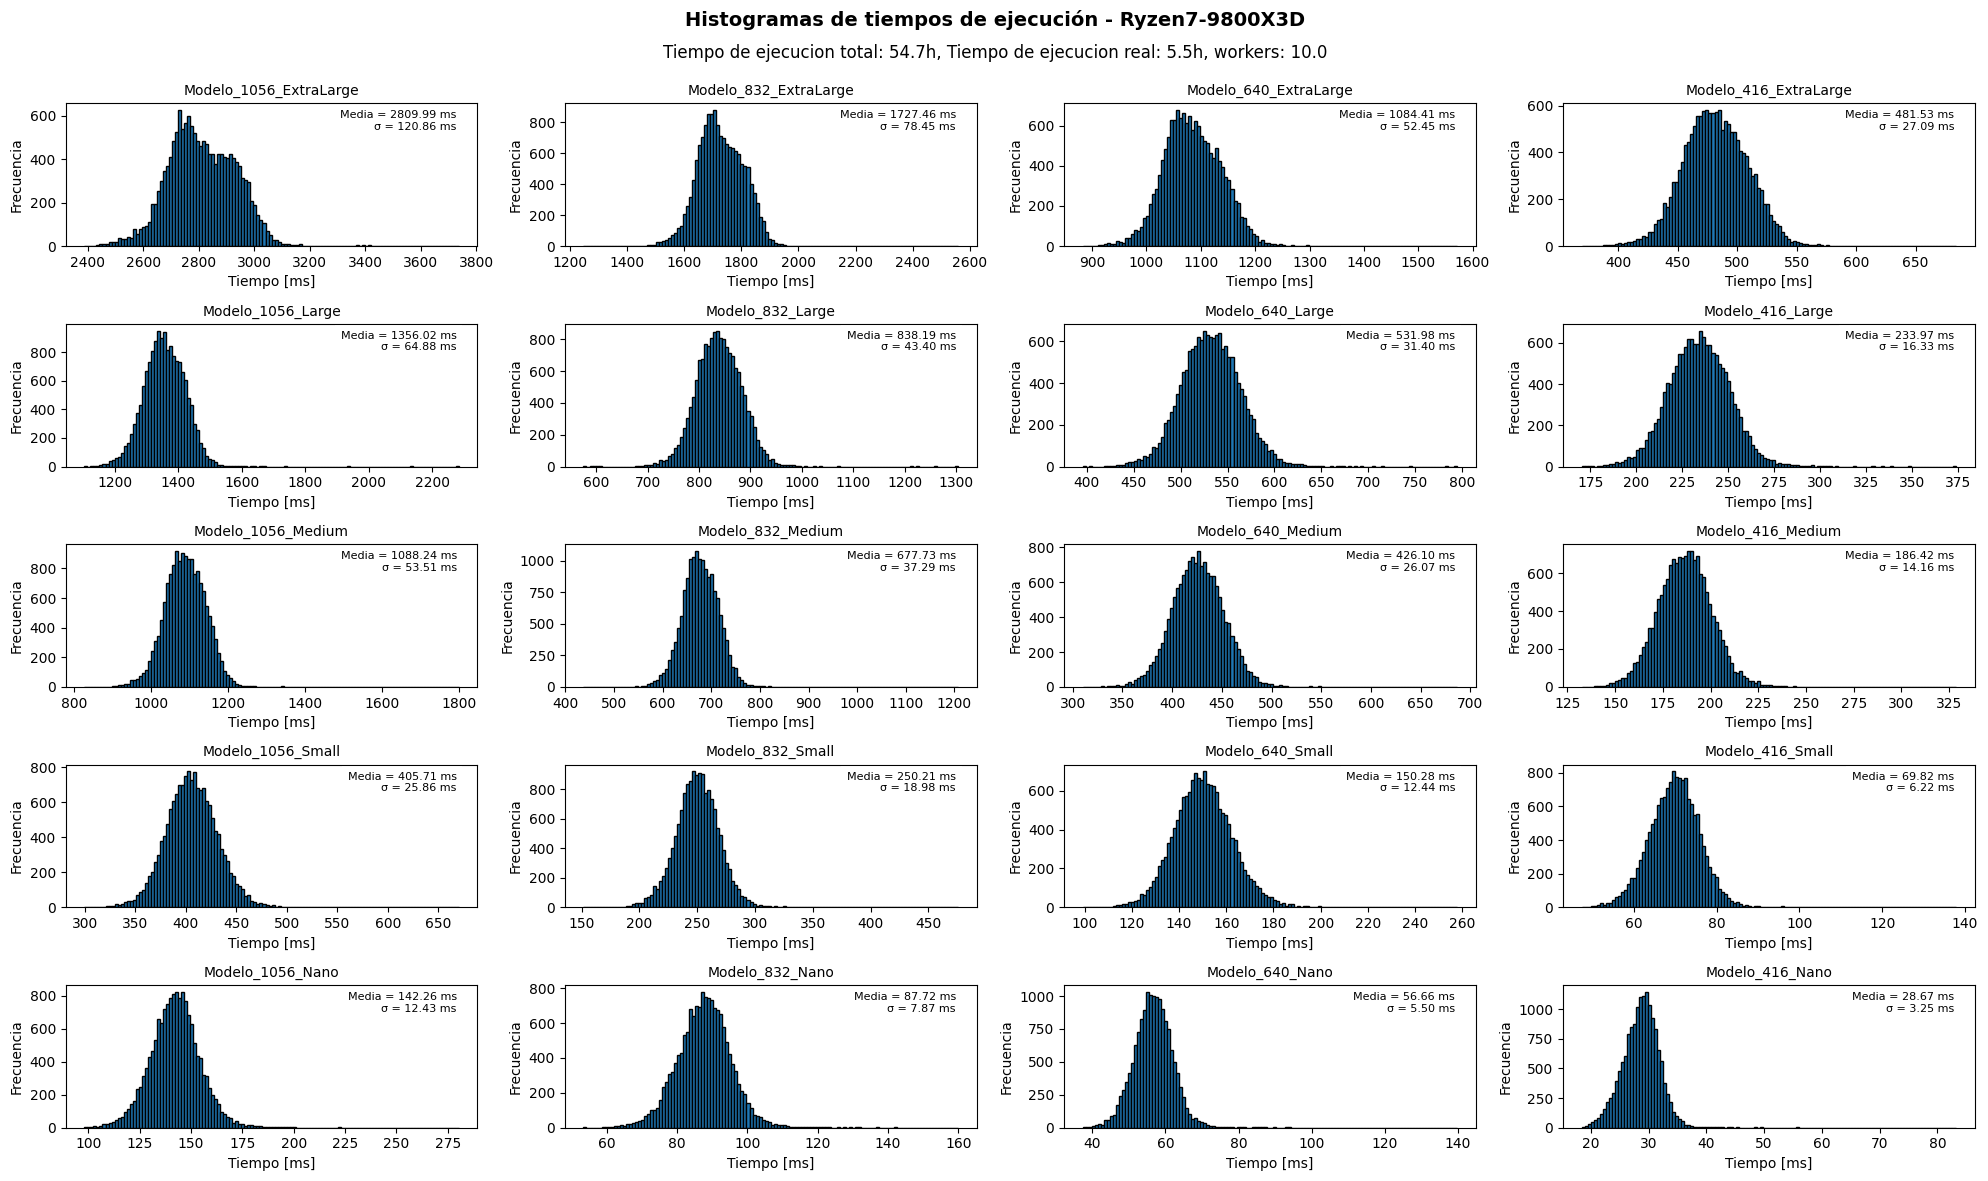

In [ ]:
Ruta_Archivos = os.path.normpath(os.path.join("..","..","..","Resultados_Segmentacion"))
Ruta_Archivos = [os.path.normpath(os.path.join(Ruta_Archivos,file))for file in os.listdir(Ruta_Archivos)]

Ruta_Salida = os.path.normpath(os.path.join("..","..",".."))


type_order = ["ExtraLarge", "Large", "Medium", "Small", "Nano"]
size_order = [1056, 832, 640, 416]

Dispositivos = {}
Resultados_Modelos = {}
Dispositivos_ordenados = {}
Cores_Dispositivos = {}

for file in Ruta_Archivos:
    Dispositivos.update(Segmentation_Results(file))
    Cores_Dispositivos[file.split("Results_")[-1].split("_")[0]] = {
        'Cores':float(file.split("_workers")[0].split("_")[-1]),
        'Total time [ms]':0}

for dispositivo, modelos in Dispositivos.items():
    modelos_ordenados = dict(
        sorted(modelos.items(), key=lambda x: modelo_sort_key(x[0], type_order, size_order))
    )
    Dispositivos_ordenados[dispositivo] = modelos_ordenados


for modelo, Resultados in next(iter(Dispositivos_ordenados.values())).items():
    Resultados_Modelos[modelo] = {
        'Embarcacion': [],
        'Falso_Negativo':[],
        'Falso_Positivo':[],
        'No_Embarcacion':[],
        'Probs':[],
        'IoU':[]
    }
    Total_Registros = Resultados['Embarcacion']+Resultados['Falso_Negativo']+Resultados['Falso_Positivo']+Resultados['No_Embarcacion']

for _, Modelos in Dispositivos_ordenados.items():
    for modelo, resultados in Modelos.items():
        for resultado, Valor in resultados.items():
            if(resultado == 'Probs'):
                for prob in Valor:
                    Resultados_Modelos[modelo][resultado].append(prob)
            elif(resultado == 'IoU'):
                for IntersectionOverUnion in Valor:
                    Resultados_Modelos[modelo][resultado].append(IntersectionOverUnion)
            elif(resultado != 'Speed'):
                Resultados_Modelos[modelo][resultado].append(Valor)

print("Matriz de confusion media - (promediado con los experimentos en diversos dispositivos)")
for modelo, resultados in Resultados_Modelos.items():
    print(f"Para el modelo {modelo}:")
    print(f"Embarcaciones: {stats.mean(resultados['Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['Embarcacion'])*100/Total_Registros}%")
    print(f"Sin embarcaciones: {stats.mean(resultados['No_Embarcacion'])*100/Total_Registros}±{stats.stdev(resultados['No_Embarcacion'])*100/Total_Registros}%")
    print(f"Falso Negativo: {stats.mean(resultados['Falso_Negativo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Negativo'])*100/Total_Registros}%")
    print(f"Falso Positivo: {stats.mean(resultados['Falso_Positivo'])*100/Total_Registros}±{stats.stdev(resultados['Falso_Positivo'])*100/Total_Registros}%")
    print(f"IoU medio: {stats.mean(resultados['IoU'])*100}±{stats.stdev(resultados['IoU'])*100}%\n")

for dispositivo, modelos in Dispositivos.items():
    print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
    for modelo, resultados in modelos.items():
        print(f"{modelo}: {stats.mean(resultados['Speed']):.2f}±{stats.stdev(resultados['Speed']):.2f} [ms]")

        for speed in resultados['Speed']:
            Cores_Dispositivos[dispositivo]['Total time [ms]']+=speed
            
    print("\n")

with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"Ejecucion_Segmentacion_Dispositivo.pdf"))) as pdf:
    for dispositivo, modelos in Dispositivos_ordenados.items():
        print(f"Para el dispositivo {dispositivo}, se tienen los siguientes tiempos de ejecucion: ")
        
        fig, axs = plt.subplots(5, 4, figsize=(20, 12))
        axs = axs.flatten()
        
        for i, (modelo, resultados) in enumerate(modelos.items()):
            if i >= 20:  
                break

            datos = resultados['Speed']
            media = stats.mean(datos)
            sigma = stats.stdev(datos)

            axs[i].hist(datos, bins=int(math.sqrt(len(datos))), edgecolor="black")
            axs[i].set_title(modelo, fontsize=10)

            axs[i].text(
                0.95, 0.95,
                f"Media = {media:.2f} ms\nσ = {sigma:.2f} ms",
                ha="right", va="top",
                transform=axs[i].transAxes,
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")  
            )

            axs[i].set_xlabel("Tiempo [ms]")
            axs[i].set_ylabel("Frecuencia")

        for j in range(i + 1, len(axs)):
            axs[j].axis("off")


        Tiempo_Total = Cores_Dispositivos[dispositivo]['Total time [ms]']/(1000*60*60)
        Tiempo_Total = f"{round(Tiempo_Total,1)}h"
        Tiempo_Real = Cores_Dispositivos[dispositivo]['Total time [ms]']/(1000*60*60*Cores_Dispositivos[dispositivo]['Cores'])
        if(Tiempo_Real<1):
            Tiempo_Real = f"{round(Tiempo_Real*60,1)}m"
        else:
            Tiempo_Real = f"{round(Tiempo_Real,1)}h"
        

        plt.suptitle(f"Histogramas de tiempos de ejecución - {dispositivo}", 
                        fontsize=14, fontweight="bold")
        fig.text(0.5, 0.94, f"Tiempo de ejecucion total: {Tiempo_Total}, Tiempo de ejecucion real: {Tiempo_Real}, workers: {Cores_Dispositivos[dispositivo]['Cores']}", ha="center", fontsize=12, fontweight="normal")

        plt.tight_layout(rect=[0, 0, 1, 0.96])

        plt.show()


        pdf.savefig(fig)
        plt.close(fig)  


La base de datos contiene un aproximado de 10966 correos diferentes
La cantidad de correos sin imagenes son: 5076, corresponde a un 46.289% de los correos

La cantidad de correos con imagenes son: 5890, corresponde a un 53.711% de los correos
Los correos que tienen imagenes pero no contienen embarcaciones son: 5280, corresponde a un 48.149% de los correos
Los correos que tienen imagenes y que contienen embarcaciones son: 610, corresponde a un 5.563% de los correos

En total se disponen de 13718 Imagenes sin embarcaciones
En total se disponen de 1877 Imagenes con embarcaciones
Se obtuvieron un total de 15595 Imagenes

Dentro de los correos se identificaron 3732 ID unicos, clasificados por el radar
El promedio de correos repetidos que llegan por ID es de: 5.539
El promedio de imagenes por correo que contiene imagenes es de: 2.648


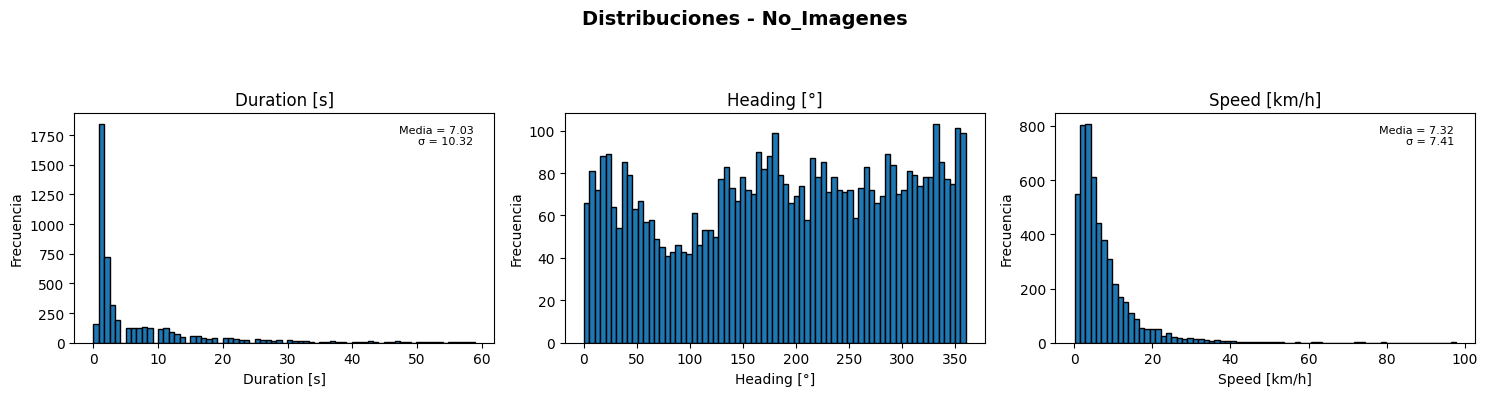

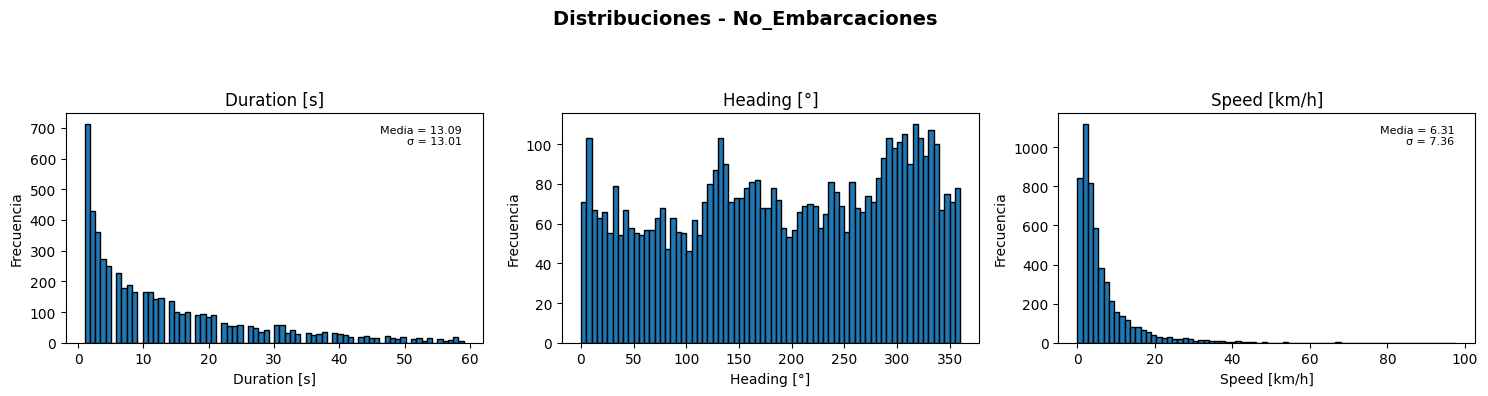

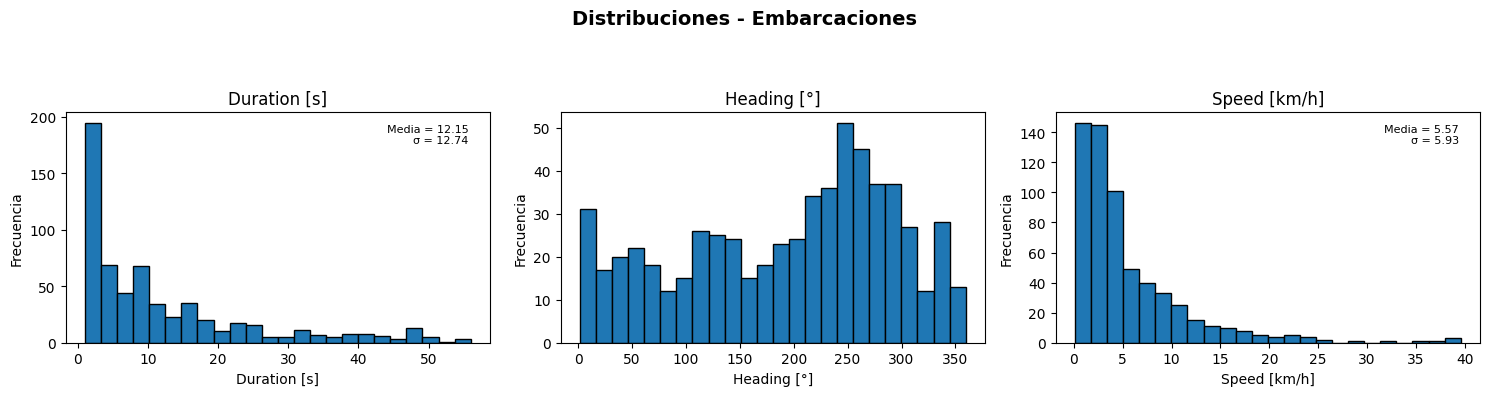

In [ ]:
Ruta_DB = os.path.normpath(os.path.join("..","..","..","DB_Embarcaciones.csv"))

Database = {
    "No_Imagenes":{
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]
    },
    "No_Embarcaciones":{
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]
    },
    "Embarcaciones":{        
        'Duration [s]':[],
        'Latitude':[],
        'Longitude':[],
        'Heading [°]':[],
        'Speed [km/h]':[],
        'System_Time':[]}}

Registros_Repetidos_No_Embarcaciones = 0
Registros_Repetidos_Embarcaciones = 0
track_subs = {}
pair_counts = {}

with open(Ruta_DB, mode="r", newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)
    header = reader.fieldnames

    # Conjunto para evitar duplicados
    registros_vistos = set()
    registros_vistos_Auxiliar = set()
    registros_imagenes_Auxiliar = set()

    for row in reader:
        # clave única: combinación de TrackID y Sub_ID
        clave_unica = (row['Track_ID'], row['Sub_ID'])
        clave_unica_auxiliar = (row['Track_ID'])

        if row['Track_ID'] not in track_subs:
                track_subs[row['Track_ID']] = 0

        track_subs[row['Track_ID']]+=1

        
        if row['Image_Name'] != 'N/A':
        
            # Contar ocurrencias del par
            if clave_unica not in pair_counts:
                pair_counts[clave_unica] = 0
            pair_counts[clave_unica] += 1





        if clave_unica_auxiliar not in registros_vistos_Auxiliar:
            registros_vistos_Auxiliar.add(clave_unica_auxiliar)


        if clave_unica in registros_vistos:
            if(row['Main_Label'] == '0'):
                Registros_Repetidos_No_Embarcaciones+=1
            elif(row['Main_Label'] == '1'):
                Registros_Repetidos_Embarcaciones+=1

            continue  # ya procesado, saltar
        registros_vistos.add(clave_unica)

        # Clasificación según tus condiciones
        if row['Image_Name'] == 'N/A':
            Database["No_Imagenes"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["No_Imagenes"]['Latitude'].append(extract_number(row['Latitude']))
            Database["No_Imagenes"]['Longitude'].append(extract_number(row['Longitude']))
            Database["No_Imagenes"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["No_Imagenes"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["No_Imagenes"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


        elif row['Main_Label'] == '0':
            Database["No_Embarcaciones"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["No_Embarcaciones"]['Latitude'].append(extract_number(row['Latitude']))
            Database["No_Embarcaciones"]['Longitude'].append(extract_number(row['Longitude']))
            Database["No_Embarcaciones"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["No_Embarcaciones"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["No_Embarcaciones"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))

        else:
            Database["Embarcaciones"]['Duration [s]'].append(extract_number(row['Duration']))
            Database["Embarcaciones"]['Latitude'].append(extract_number(row['Latitude']))
            Database["Embarcaciones"]['Longitude'].append(extract_number(row['Longitude']))
            Database["Embarcaciones"]['Heading [°]'].append(extract_number(row['Heading']))
            Database["Embarcaciones"]['Speed [km/h]'].append(extract_number(row['Speed']))
            Database["Embarcaciones"]['System_Time'].append(datetime.strptime(row['System_Time'], "%Y-%m-%d %H:%M:%S"))


for categoria, datos in Database.items():
    if (categoria == 'No_Imagenes'):
        Correos_Sin_Imagenes = len(datos['Duration [s]'])
    elif (categoria == 'No_Embarcaciones'):
        Correos_Sin_Embarcaciones = len(datos['Duration [s]'])
    else:
        Correos_Con_Embarcaciones = len(datos['Duration [s]'])

conteos_subs_per_ID = [subs for subs in track_subs.values()]
promedio_subs_por_track = round(sum(conteos_subs_per_ID) / len(conteos_subs_per_ID),3) if conteos_subs_per_ID else 0

conteos_Img_per_subs = [img for img in pair_counts.values()]
promedio_img_por_subs = round(sum(conteos_Img_per_subs) / len(conteos_Img_per_subs),3) if conteos_Img_per_subs else 0

Total_Correos=Correos_Sin_Imagenes+Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones
Total_Imagenes=Correos_Sin_Embarcaciones+Registros_Repetidos_No_Embarcaciones+Correos_Con_Embarcaciones+Registros_Repetidos_Embarcaciones

print(f"La base de datos contiene un aproximado de {Total_Correos} correos diferentes")
print(f"La cantidad de correos sin imagenes son: {Correos_Sin_Imagenes}, corresponde a un {round(Correos_Sin_Imagenes*100/Total_Correos,3)}% de los correos\n")

print(f"La cantidad de correos con imagenes son: {Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones}, corresponde a un {round((Correos_Sin_Embarcaciones+Correos_Con_Embarcaciones)*100/Total_Correos,3)}% de los correos")
print(f"Los correos que tienen imagenes pero no contienen embarcaciones son: {Correos_Sin_Embarcaciones}, corresponde a un {round(Correos_Sin_Embarcaciones*100/Total_Correos,3)}% de los correos")
print(f"Los correos que tienen imagenes y que contienen embarcaciones son: {Correos_Con_Embarcaciones}, corresponde a un {round(Correos_Con_Embarcaciones*100/Total_Correos,3)}% de los correos\n")

print(f"En total se disponen de {Correos_Sin_Embarcaciones+Registros_Repetidos_No_Embarcaciones} Imagenes sin embarcaciones")
print(f"En total se disponen de {Correos_Con_Embarcaciones+Registros_Repetidos_Embarcaciones} Imagenes con embarcaciones")
print(f"Se obtuvieron un total de {Total_Imagenes} Imagenes\n")

print(f"Dentro de los correos se identificaron {len(registros_vistos_Auxiliar)} ID unicos, clasificados por el radar")
print(f"El promedio de correos repetidos que llegan por ID es de: {promedio_subs_por_track}")
print(f"El promedio de imagenes por correo que contiene imagenes es de: {promedio_img_por_subs}")


with PdfPages(os.path.normpath(os.path.join(Ruta_Salida,"histogramas_DB.pdf"))) as pdf:

    for categoria, variables in Database.items():
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"Distribuciones - {categoria}", fontsize=14, fontweight="bold")

        columnas = ["Duration [s]", "Heading [°]", "Speed [km/h]"]

        for idx, nombre_var in enumerate(columnas):
            ax = axs[idx]
            valores = variables.get(nombre_var, [])

            if len(valores) > 0:
                ax.hist(valores, bins=int(math.sqrt(len(valores))), edgecolor="black")
                ax.set_title(nombre_var)
                ax.set_xlabel(nombre_var)
                ax.set_ylabel("Frecuencia")

                # Calcular media y desviación estándar solo en Duration y Speed
                if nombre_var in ["Duration [s]", "Speed [km/h]"] and len(valores) > 1:
                    media = stats.mean(valores)
                    sigma = stats.stdev(valores)

                    ax.text(
                        0.95, 0.95,
                        f"Media = {media:.2f}\nσ = {sigma:.2f}",
                        ha="right", va="top",
                        transform=ax.transAxes,
                        fontsize=8,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                    )
            else:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center")
                ax.set_title(nombre_var)

        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.show()

        pdf.savefig(fig)
        plt.close(fig)  




Promedio y desviación estándar de correos por día (solo días con correos):
- No_Imagenes: media = 126.90, std = 179.98
- No_Embarcaciones: media = 146.67, std = 219.81
- Embarcaciones: media = 19.06, std = 34.14


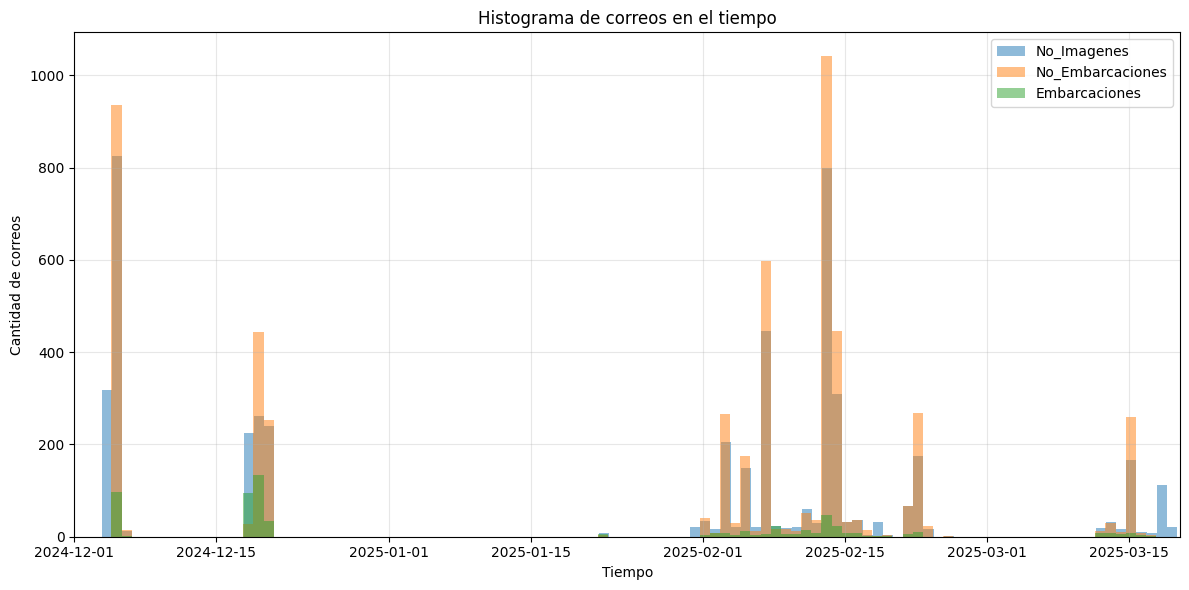

In [ ]:
import pandas as pd


plt.figure(figsize=(12,6))
estadisticas = {}

for categoria, datos in Database.items():
    if len(datos["System_Time"]) > 0:
        times = pd.to_datetime(datos["System_Time"])
        min_time = times.min()
        max_time = times.max()
        # Correos por día
        correos_por_dia = pd.Series(1, index=times).groupby(times.date).count()
        
        # Calcular media y desviación estándar
        media = correos_por_dia.mean()
        std = correos_por_dia.std()
        
        estadisticas[categoria] = (media, std)

        # Definir número de bins = número de días o semanas
        bins = pd.date_range(start=min_time, end=max_time, freq='D')  # un bin por día
        plt.hist(times, bins=bins, alpha=0.5, label=categoria)

print("\nPromedio y desviación estándar de correos por día (solo días con correos):")
for categoria, (media, std) in estadisticas.items():
    print(f"- {categoria}: media = {media:.2f}, std = {std:.2f}")


fecha_min = pd.to_datetime("2024-12-01 00:00:00")
fecha_max = pd.to_datetime("2025-3-20 00:00:00")
plt.xlim(fecha_min, fecha_max)

plt.title("Histograma de correos en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de correos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
estadisticas_imagenes = {}

# ---- Imágenes sin embarcaciones ----
if len(Database["No_Embarcaciones"]["System_Time"]) > 0:
    times_no_emb = pd.to_datetime(Database["No_Embarcaciones"]["System_Time"])
    fechas_no_emb = times_no_emb.date
    conteo_no_emb = pd.Series(1, index=fechas_no_emb).groupby(level=0).sum()

    # Añadir repetidos al último día (ajusta según tu lógica)
    if Registros_Repetidos_No_Embarcaciones > 0:
        conteo_no_emb.iloc[-1] += Registros_Repetidos_No_Embarcaciones

    estadisticas_imagenes["No_Embarcaciones"] = (
        conteo_no_emb.mean(),
        conteo_no_emb.std()
    )

# ---- Imágenes con embarcaciones ----
if len(Database["Embarcaciones"]["System_Time"]) > 0:
    times_emb = pd.to_datetime(Database["Embarcaciones"]["System_Time"])
    fechas_emb = times_emb.date
    conteo_emb = pd.Series(1, index=fechas_emb).groupby(level=0).sum()

    if Registros_Repetidos_Embarcaciones > 0:
        conteo_emb.iloc[-1] += Registros_Repetidos_Embarcaciones

    estadisticas_imagenes["Embarcaciones"] = (
        conteo_emb.mean(),
        conteo_emb.std()
    )

# ---- Total imágenes (suma de ambas) ----
if "No_Embarcaciones" in estadisticas_imagenes and "Embarcaciones" in estadisticas_imagenes:
    total_series = conteo_no_emb.add(conteo_emb, fill_value=0)
    estadisticas_imagenes["Total_Imagenes"] = (
        total_series.mean(),
        total_series.std()
    )

# ---- Mostrar resultados ----
print("\nPromedio y desviación estándar de imágenes por día (solo días con imágenes):")
for categoria, (media, std) in estadisticas_imagenes.items():
    print(f"- {categoria}: media = {media:.2f}, std = {std:.2f}")



Promedio y desviación estándar de imágenes por día (solo días con imágenes):
- No_Embarcaciones: media = 381.06, std = 1412.24
- Embarcaciones: media = 58.66, std = 223.83
- Total_Imagenes: media = 433.19, std = 1621.12


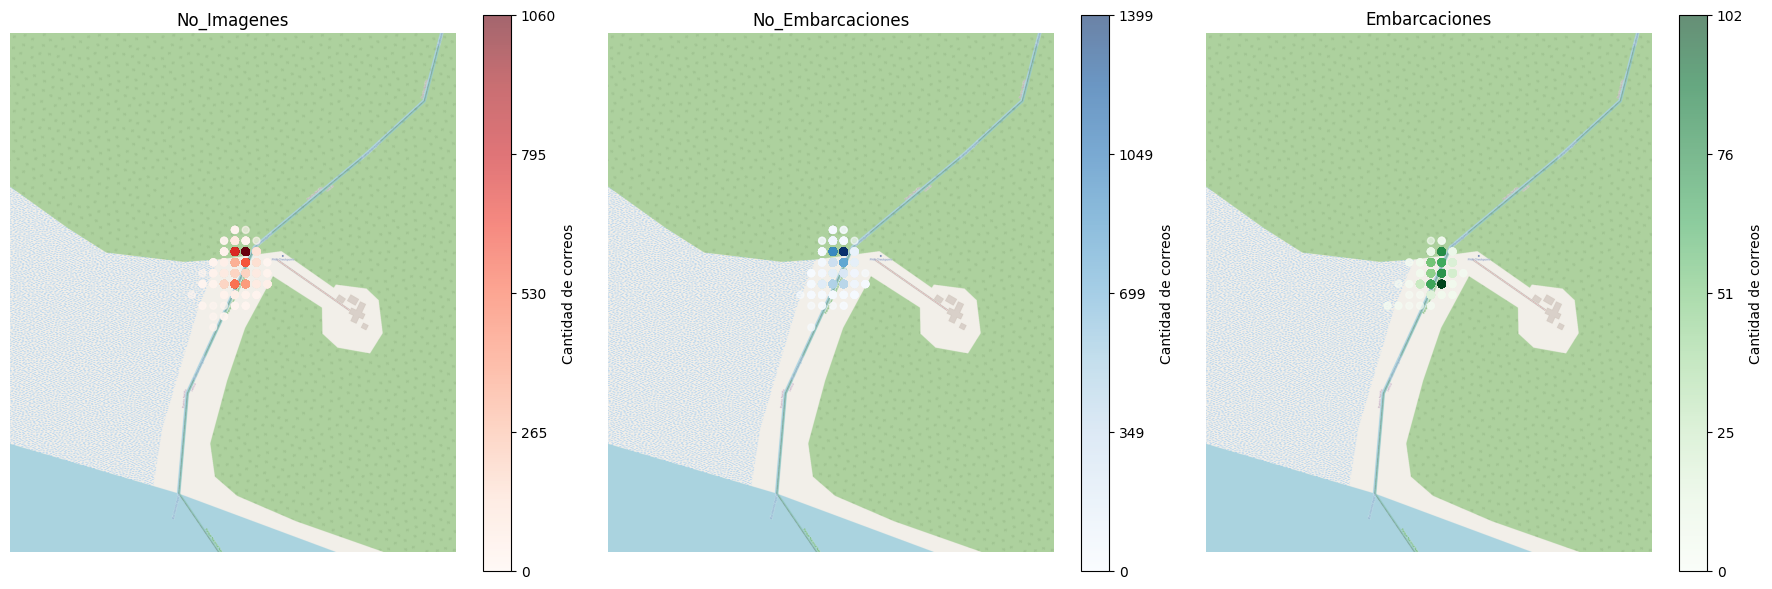

In [ ]:
# -----------------------------
# Área de interés
# -----------------------------
center_lat = -3.805534
center_lon = -70.306282
lat_margin = 0.002
lon_margin = 0.002

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
minx, miny = transformer.transform(center_lon - lon_margin, center_lat - lat_margin)
maxx, maxy = transformer.transform(center_lon + lon_margin, center_lat + lat_margin)

# -----------------------------
# Descargar mapa base
# -----------------------------
img, ext = ctx.bounds2img(minx, miny, maxx, maxy, zoom=19, source=ctx.providers.OpenStreetMap.Mapnik)

# -----------------------------
# Crear GeoDataFrame de puntos
# -----------------------------
points = []
categories = []

for key in Database:
    lats = Database[key]['Latitude']
    lons = Database[key]['Longitude']
    for lat, lon in zip(lats, lons):
        points.append(Point(lon, lat))
        categories.append(key)

gdf = gpd.GeoDataFrame({'category': categories}, geometry=points, crs='EPSG:4326')
gdf_web = gdf.to_crs(epsg=3857)
gdf_web = gdf_web.cx[minx:maxx, miny:maxy]

# -----------------------------
# Colormap por categoría
# -----------------------------
categories_unique = gdf_web['category'].unique()
cmap_dict = {'No_Imagenes':'Reds', 'No_Embarcaciones':'Blues', 'Embarcaciones':'Greens'}

# -----------------------------
# Figura con 3 subplots usando scatter con conteo real
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, cat in zip(axes, categories_unique):
    subset = gdf_web[gdf_web['category']==cat]
    if subset.empty:
        continue
    
    x = subset.geometry.x.values
    y = subset.geometry.y.values
    
    # -----------------------------
    # Contar cantidad de puntos en un grid
    # -----------------------------
    gridsize = 50  # Ajusta resolución
    H, xedges, yedges = np.histogram2d(x, y, bins=gridsize, range=[[minx,maxx],[miny,maxy]])
    
    # Asignar a cada punto el conteo de la celda donde cae
    x_idx = np.searchsorted(xedges, x) - 1
    y_idx = np.searchsorted(yedges, y) - 1
    z = H[x_idx, y_idx]
    
    # -----------------------------
    # Plot
    # -----------------------------
    ax.imshow(img, extent=ext, zorder=0)
    
    vmax = np.max(z)  # valor máximo para la colorbar
    sc = ax.scatter(x, y, c=z, s=25, cmap=cmap_dict.get(cat,'hot'), alpha=0.6,
                    vmin=0, vmax=vmax)
    
    cbar = plt.colorbar(sc, ax=ax, label='Cantidad de correos')  
    cbar.set_ticks(np.linspace(0, vmax, num=5))
    cbar.ax.set_yticklabels([f"{int(t)}" for t in np.linspace(0, vmax, num=5)])
    
    ax.set_axis_off()
    ax.set_title(cat)

plt.tight_layout()
#plt.savefig("mapa_calor_scatter_cantidad_3categorias_max.png", dpi=300)
plt.show()

In [ ]:
import shutil
from ultralytics import YOLO
import cv2

Ruta_Base = os.path.normpath(os.path.join("..","..",".."))
Nombre_DB = "DB_Embarcaciones.csv"
Nombre_Carpeta = "Imagenes_Embarcaciones"
Nombre_Modelo = os.path.normpath(os.path.join("Model_Training",
                                              "YoloV11_Segmentation_Experimental-Result",
                                              "runs",
                                              "Modelo_416_Nano",
                                              "weights",
                                              "best.pt"))

dir_path = os.path.normpath(os.path.join(Ruta_Base,Nombre_Carpeta))
db_path = os.path.normpath(os.path.join(Ruta_Base,Nombre_DB))
model_path = os.path.normpath(os.path.join(Ruta_Base,Nombre_Modelo))
raw_path = os.path.normpath(os.path.join(dir_path,"Raw"))
yolo_path = os.path.normpath(os.path.join(dir_path,"Yolo"))

model = YOLO(model_path)                        # YOLOV11 con el entrenamiento custom
model.to("cuda")        

if not os.path.exists(dir_path):    
    os.makedirs(dir_path)
    os.makedirs(raw_path)
    os.makedirs(yolo_path)

with open(db_path, mode="r", newline='', encoding='utf-8') as infile:
            
    reader = csv.DictReader(infile)         # Lee el Header Original
    count = 0
    for row in reader:                      # Por cada elemento del archivo CSV
        if row["Image_Name"] != "N/A" and row["Main_Label"]=="1":
            count += 1
            ruta = f"{row["Path"]}\\{row["Image_Path"]}\\{row["Image_Name"]}"
            ruta = os.path.normpath(os.path.join(Ruta_Base,ruta.split("..\\")[-1]))
            ext = os.path.splitext(ruta)[1]                             # Obtiene el tipo de extension de la imagen
            imagen = cv2.imread(ruta)                                                               # Lee la imagen
            predict = model(ruta, verbose=False)[0]    # Prediccion del modelo YOLOV11

            if len(predict.boxes.xyxy.tolist())>0:         # Si YOLOV11 realizo la prediccion
                xyxy = [[int(item) for item in subitem ] for subitem in predict.boxes.xyxy.tolist()]
                
                for (x1, y1, x2, y2), prob in zip(xyxy,predict.boxes.conf.tolist()):  # Dibuja los segmentos generados por YOLOV11 en caso de existir
                    cv2.rectangle(imagen, (x1,y1),(x2,y2),(255, 229, 180),2)          
                    cv2.putText(imagen, f"{prob:.2f}", (x1 - 15, y1 - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 100), 2)
            
            shutil.copy2(ruta, os.path.join(raw_path,str(count)+ext))     
            cv2.imwrite(os.path.join(yolo_path,str(count)+ext), imagen)

print(f"equisde: {count}")


equisde: 1877


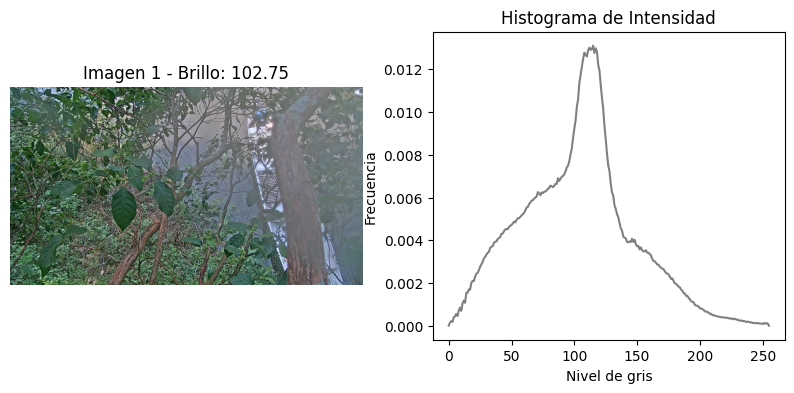

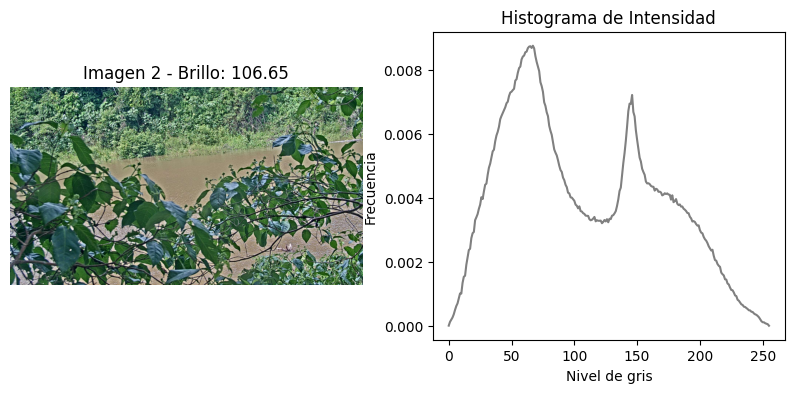

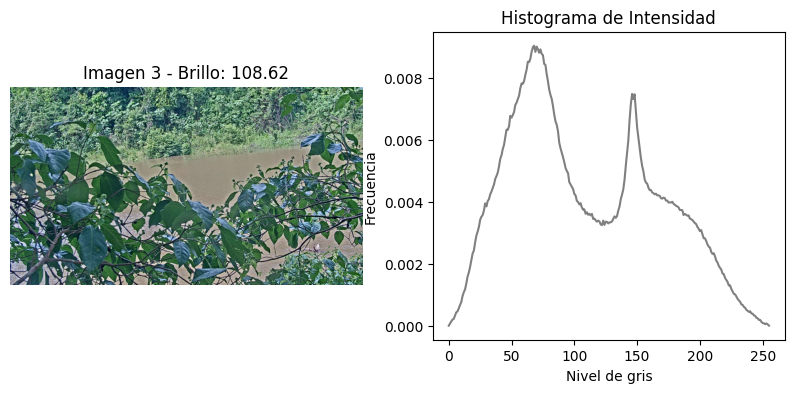

Se analizaron 15595 imágenes
La cantidad de imagenes de noche es de: 4303


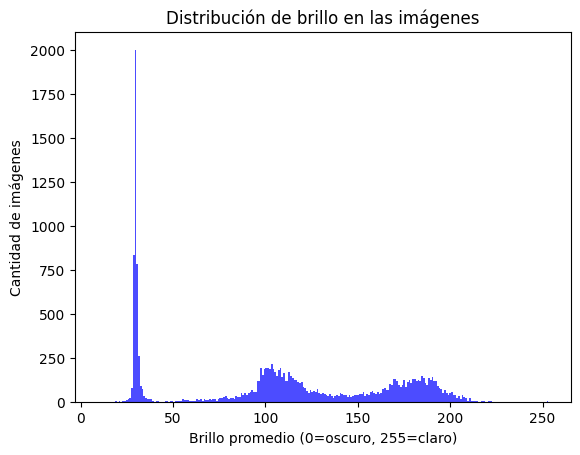

In [ ]:
import shutil
import cv2

Ruta_Base = os.path.normpath(os.path.join("..","..",".."))
Nombre_DB = "DB_Embarcaciones.csv"
Nombre_Carpeta = "Imagenes_Embarcaciones_Noche"

dir_path = os.path.normpath(os.path.join(Ruta_Base,Nombre_Carpeta))
db_path = os.path.normpath(os.path.join(Ruta_Base,Nombre_DB))

brillos = []
count_noche = 0

if not os.path.exists(dir_path):    
    os.makedirs(dir_path)

with open(db_path, mode="r", newline='', encoding='utf-8') as infile:
            
    reader = csv.DictReader(infile)         # Lee el Header Original
    count = 0
    for row in reader:                      # Por cada elemento del archivo CSV
        if row["Image_Name"] != "N/A":
            count += 1
            ruta = f"{row["Path"]}\\{row["Image_Path"]}\\{row["Image_Name"]}"
            ruta = os.path.normpath(os.path.join(Ruta_Base,ruta.split("..\\")[-1]))
            ext = os.path.splitext(ruta)[1]                             # Obtiene el tipo de extension de la imagen
            imagen = cv2.imread(ruta)                                                               # Lee la imagen

            # Convertir a escala de grises
            gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

            # Calcular histograma
            hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

            # Normalizar histograma
            hist = hist / hist.sum()

            # Calcular brillo promedio
            brillo_prom = np.mean(gris)
            brillos.append(brillo_prom)

            # (Opcional) Mostrar primeras imágenes con su histograma
            if count <= 3:
                plt.figure(figsize=(10,4))
                plt.subplot(1,2,1)
                plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
                plt.title(f"Imagen {count} - Brillo: {brillo_prom:.2f}")
                plt.axis("off")

                plt.subplot(1,2,2)
                plt.plot(hist, color='gray')
                plt.title("Histograma de Intensidad")
                plt.xlabel("Nivel de gris")
                plt.ylabel("Frecuencia")
                plt.show()


            if (brillo_prom < 50):  
                count_noche+=1
                shutil.copy2(ruta, os.path.join(dir_path,str(count)+ext))     
                # cv2.imwrite(os.path.join(yolo_path,str(count)+ext), imagen)

print(f"Se analizaron {count} imágenes")
print(f"La cantidad de imagenes de noche es de: {count_noche}")
# Distribución general de brillos
plt.hist(brillos, bins=255, color='blue', alpha=0.7)
plt.title("Distribución de brillo en las imágenes")
plt.xlabel("Brillo promedio (0=oscuro, 255=claro)")
plt.ylabel("Cantidad de imágenes")
plt.show()

